# Ver.5 実装前チェック（VG1GC-66）

[docs/requirements_ver5.md](../docs/requirements_ver5.md) の設計レビューで挙がった「実装前にやると安い確認」4件を実行するノート。Ver.5本体の実装ではなく、**着手前に前提が成り立っているかを確かめるための記述統計・小規模フィット**に限定する。

| # | 確認内容 | 何が分かれば良いか |
| :--- | :--- | :--- |
| 1 | 日別の学習曲線と day6 の点検 | Day 1–15がこの個体で実際に学習過程を張っているか。5.2節のランダムウォーク事前分布が前提とする「day間の緩やかな変化」が成り立つか |
| 2 | Short Pull の3類型分解と時間的まとまり | 系統B（3値）が区別しようとしている境界に、状態が捉えうる系統的構造があるか。センサーの接触判定由来の成分を除いても残るか |
| 3 | $P(z)\geq0.8$ の残存率と 状態×試行タイプ のday別セル数 | 6節の皮質デコード（閾値・バランシング）が試行数的に成立するか |
| 4 | `ssm` の `InputDrivenObservations(C=3)` で3値静的GLM-HMMが回るか | 系統Bの静的フィット（5.4節Step (1)）に自前実装が要るか |

前提: `VG1GC-66` の全14 task-day（day1, 3–15）のNWBがローカルに揃っていること（[docs/data.md](../docs/data.md)）。

## 0. セットアップ

In [1]:
import sys, os
from pathlib import Path

IN_COLAB = False
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    pass

if IN_COLAB:
    drive.mount('/content/drive')
    repo_path = Path('/content/braidyn-bc')
    if not repo_path.exists():
        os.system('git clone https://github.com/nyaamikeneko/braidyn-bc.git /content/braidyn-bc')
    os.chdir(repo_path)
else:
    here = Path.cwd()
    repo_root = here if (here / 'config.py').exists() else here.parent
    os.chdir(repo_root)

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))
print('cwd:', Path.cwd())

cwd: /mnt/c/Users/dmasu/braidyn-bc


In [2]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import config
import src.glmhmm_ver4 as v4

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)

MOUSE_ID = 'VG1GC-66'
ALPHA_ACT = v4.ALPHA_ACT   # 0.65
ALPHA_REW = v4.ALPHA_REW   # 0.80
SOUND_TYPES = ['Success', 'Short Pull', 'No Reaction']
NUM_STATES = 3
PRIOR_SIGMA = v4.PRIOR_SIGMA
SEEDS = [0, 1, 2]
NUM_ITERS = 200
P_THRESHOLD = 0.80   # 6.1節 Aloor式の状態割り当て閾値

print(f'mouse={MOUSE_ID} alpha_act={ALPHA_ACT} alpha_rew={ALPHA_REW}')

環境: ローカル (WSL)
DATA_CSV_ROOT: /mnt/g/.shortcut-targets-by-id/1fI6PWRHgihU6asA4OyW-_rN-JII33Fkj/hackathon_data
DATA_CSV_BACKUP_ROOT: /mnt/g/マイドライブ/braidyn-bc-backup/hackathon_data


mouse=VG1GC-66 alpha_act=0.65 alpha_rew=0.8


## 1. Ver.5の試行系列を作る

[requirements_ver5.md](../docs/requirements_ver5.md) 2.1節に従い、Ver.4の試行テーブルから**音提示試行のみ**（Success / Short Pull / No Reaction）を取り出して単一系列にする。No Sound Pull と Second Pull は落とす。

入力（4.2節）はこの音提示試行だけの系列で計算し直す。History のday境界での扱いは要件に規定が無いので、**ここではday頭でリセット**する（Ver.4の `add_history` と同じ挙動）。History 2列は4.2節に従い全日プールでz-score化する。

In [3]:
# NWBの読み込みは数分かかるので、試行テーブルと日別サマリーをローカルにキャッシュする。
# （data/ は .gitignore 済み。キャッシュを消せば再構築される）
CACHE_DIR = Path('data') / 'cache'
CACHE_TRIALS = CACHE_DIR / f'ver5_trials_{MOUSE_ID}.pkl'
CACHE_SESS = CACHE_DIR / f'ver5_session_summary_{MOUSE_ID}.pkl'

if CACHE_TRIALS.exists() and CACHE_SESS.exists():
    trials_all = pd.read_pickle(CACHE_TRIALS)
    sess_raw = pd.read_pickle(CACHE_SESS)
    print('キャッシュから読み込み:', CACHE_TRIALS)
else:
    dataset = v4.process_mouse(MOUSE_ID, alpha_act=ALPHA_ACT, alpha_rew=ALPHA_REW)
    trials_all = dataset['trials']
    rows = []
    for pack in dataset['sessions']:
        cl = pack['cleaned']
        rows.append({
            'task_day': pack['trials']['task_day'].iloc[0],
            'session_min': float(cl['t'].max() - cl['t'].min()) / 60.0,
            'frac_ITI_time': float(cl['state_task'].eq(0).mean()),
        })
    sess_raw = pd.DataFrame(rows)
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    trials_all.to_pickle(CACHE_TRIALS)
    sess_raw.to_pickle(CACHE_SESS)
    print('キャッシュを作成:', CACHE_TRIALS)

print()
print('Ver.4 全試行タイプの内訳:')
print(trials_all['trial_type'].value_counts())
print('task_days:', list(dict.fromkeys(trials_all['task_day'])))

キャッシュから読み込み: data/cache/ver5_trials_VG1GC-66.pkl

Ver.4 全試行タイプの内訳:
trial_type
No Sound Pull    4386
Success          1293
No Reaction       555
Short Pull        511
Name: count, dtype: int64
task_days: ['task-day1', 'task-day3', 'task-day4', 'task-day5', 'task-day6', 'task-day7', 'task-day8', 'task-day9', 'task-day10', 'task-day11', 'task-day12', 'task-day13', 'task-day14', 'task-day15']


In [4]:
def build_ver5_sequence(trials_all, alpha_act=ALPHA_ACT, alpha_rew=ALPHA_REW):
    # 音提示試行のみの系列を作り、その系列上でHistoryを計算し直す（day頭でリセット）
    out = []
    for day, g in trials_all.groupby('task_day', sort=False):
        g = g[g['trial_type'].isin(SOUND_TYPES)].sort_values('t_start').reset_index(drop=True).copy()
        a = (g['trial_type'] != 'No Reaction').astype(int).to_numpy()
        rw = (g['trial_type'] == 'Success').astype(int).to_numpy()
        n = len(g)
        h = np.zeros(n); r = np.zeros(n)
        for k in range(1, n):
            h[k] = a[k - 1] + alpha_act * h[k - 1]
            r[k] = rw[k - 1] + alpha_rew * r[k - 1]
        g['a'] = a
        g['reward_bin'] = rw
        g['x_bias'] = 1.0
        g['x_hist'] = h
        g['x_rew'] = r
        g['yA'] = a
        g['yB'] = g['trial_type'].map({'Success': 0, 'Short Pull': 1, 'No Reaction': 2}).astype(int)
        g['k'] = np.arange(n)
        out.append(g)
    return pd.concat(out, ignore_index=True)

tr = build_ver5_sequence(trials_all)

# 4.2節: History 2列は全日プールでz-score化（Bias列はそのまま）
ZSTATS = {}
for c in ['x_hist', 'x_rew']:
    mu, sd = float(tr[c].mean()), float(tr[c].std(ddof=0))
    ZSTATS[c] = (mu, sd)
    tr[c + '_z'] = (tr[c] - mu) / sd
INPUT_COLS = ['x_bias', 'x_hist_z', 'x_rew_z']

DAYS = list(dict.fromkeys(tr['task_day'].tolist()))
print('days:', len(DAYS), DAYS)
print('音提示試行 総数:', len(tr))
print(tr['trial_type'].value_counts())
print()
print('z-score前の入力レンジ（4.2節の標準化の根拠）:')
print(tr[['x_bias', 'x_hist', 'x_rew']].describe().loc[['min', 'max', 'mean', 'std']].round(3))
print('z-score統計 (mean, sd):', {k: (round(v[0], 3), round(v[1], 3)) for k, v in ZSTATS.items()})

days: 14 ['task-day1', 'task-day3', 'task-day4', 'task-day5', 'task-day6', 'task-day7', 'task-day8', 'task-day9', 'task-day10', 'task-day11', 'task-day12', 'task-day13', 'task-day14', 'task-day15']
音提示試行 総数: 2359
trial_type
Success        1293
No Reaction     555
Short Pull      511
Name: count, dtype: int64

z-score前の入力レンジ（4.2節の標準化の根拠）:
      x_bias  x_hist  x_rew
min      1.0   0.000  0.000
max      1.0   2.857  4.994
mean     1.0   2.145  2.649
std      0.0   0.860  1.318
z-score統計 (mean, sd): {'x_hist': (2.145, 0.86), 'x_rew': (2.649, 1.318)}


## 2. チェック1: 日別の学習曲線と day6 の点検

要件5.2節のランダムウォーク事前分布は「dayをまたいで重みが緩やかに変化する」ことを前提にしている。またRQ2は「Day 1–15が学習過程を張っている」ことを前提にしている。まずこの2つの前提を行動データだけで確かめる。

In [5]:
rows = []
for day in DAYS:
    g = tr[tr['task_day'] == day]
    n = len(g)
    n_pull = int((g['trial_type'] != 'No Reaction').sum())
    n_succ = int((g['trial_type'] == 'Success').sum())
    thr = g['pull_duration_for_success'].dropna()
    rows.append({
        'task_day': day,
        'n_trials': n,
        'p_no_reaction': (g['trial_type'] == 'No Reaction').mean(),
        'p_success_all': n_succ / n,
        'p_success_given_pull': (n_succ / n_pull) if n_pull else np.nan,
        'n_pull': n_pull,
        'thr_median': float(thr.median()) if len(thr) else np.nan,
        'thr_min': float(thr.min()) if len(thr) else np.nan,
        'thr_max': float(thr.max()) if len(thr) else np.nan,
    })
day_stats = pd.DataFrame(rows)
day_stats['day_idx'] = np.arange(1, len(day_stats) + 1)
day_stats['day_num'] = day_stats['task_day'].str.extract(r'(\d+)$').astype(int)
print(day_stats.round(3).to_string(index=False))

  task_day  n_trials  p_no_reaction  p_success_all  p_success_given_pull  n_pull  thr_median  thr_min  thr_max  day_idx  day_num
 task-day1        76          0.421          0.579                 1.000      44        0.00     0.00     0.05        1        1
 task-day3       156          0.346          0.571                 0.873     102        0.05     0.00     0.15        2        3
 task-day4       103          0.049          0.883                 0.929      98        0.15     0.05     0.30        3        4
 task-day5       183          0.098          0.749                 0.830     165        0.40     0.30     0.40        4        5
 task-day6       318          0.610          0.280                 0.718     124        0.40     0.30     0.40        5        6
 task-day7       157          0.070          0.726                 0.781     146        0.40     0.30     0.40        6        7
 task-day8       153          0.235          0.438                 0.573     117        0.30     

In [6]:
def trend(y, x):
    y = np.asarray(y, dtype=float); x = np.asarray(x, dtype=float)
    ok = np.isfinite(y) & np.isfinite(x)
    rho, p_s = stats.spearmanr(x[ok], y[ok])
    r, p_p = stats.pearsonr(x[ok], y[ok])
    return rho, p_s, r, p_p

print('day index に対する単調傾向（n=14 day）')
print(f"{'metric':24s} {'spearman':>9s} {'p':>7s} {'pearson':>9s} {'p':>7s}")
for m in ['p_no_reaction', 'p_success_all', 'p_success_given_pull', 'thr_median', 'n_trials']:
    rho, ps, r, pp = trend(day_stats[m], day_stats['day_idx'])
    print(f'{m:24s} {rho:9.3f} {ps:7.3f} {r:9.3f} {pp:7.3f}')

dnr = day_stats['p_no_reaction'].to_numpy()
print()
print('隣接day間の No Reaction率 の変化量:', np.round(np.abs(np.diff(dnr)), 3))
print(f'  平均 {np.abs(np.diff(dnr)).mean():.3f} / 最大 {np.abs(np.diff(dnr)).max():.3f}')

day index に対する単調傾向（n=14 day）
metric                    spearman       p   pearson       p
p_no_reaction               -0.086   0.771    -0.223   0.443
p_success_all               -0.354   0.215    -0.298   0.301
p_success_given_pull        -0.670   0.009    -0.718   0.004
thr_median                   0.069   0.815     0.018   0.951
n_trials                     0.317   0.270     0.272   0.347

隣接day間の No Reaction率 の変化量: [0.075 0.298 0.05  0.512 0.54  0.165 0.055 0.11  0.015 0.129 0.024 0.113
 0.193]
  平均 0.175 / 最大 0.540


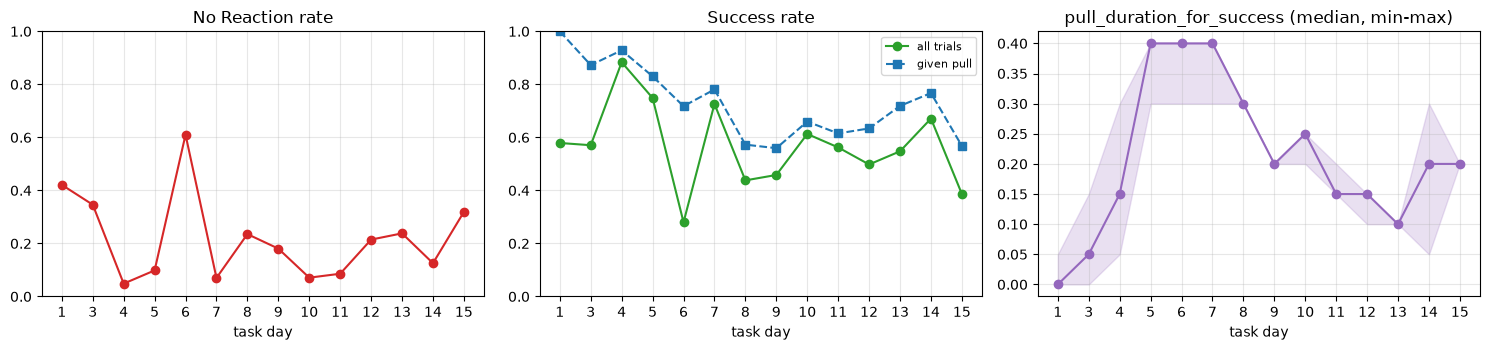

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
x = day_stats['day_idx']
labels = day_stats['day_num'].astype(str)

axes[0].plot(x, day_stats['p_no_reaction'], 'o-', color='#d62728')
axes[0].set_title('No Reaction rate'); axes[0].set_ylim(0, 1)
axes[1].plot(x, day_stats['p_success_all'], 'o-', color='#2ca02c', label='all trials')
axes[1].plot(x, day_stats['p_success_given_pull'], 's--', color='#1f77b4', label='given pull')
axes[1].set_title('Success rate'); axes[1].set_ylim(0, 1); axes[1].legend(fontsize=8)
axes[2].plot(x, day_stats['thr_median'], 'o-', color='#9467bd')
axes[2].fill_between(x, day_stats['thr_min'], day_stats['thr_max'], alpha=.2, color='#9467bd')
axes[2].set_title('pull_duration_for_success (median, min-max)')
for ax in axes:
    ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_xlabel('task day'); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [8]:
# セッションレベルの点検（day6の外れ値性を含む）
rows = []
for _, srow in sess_raw.iterrows():
    day = srow['task_day']
    g = tr[tr['task_day'] == day]
    dur_min = float(srow['session_min'])
    thirds = np.array_split(g['trial_type'].to_numpy(), 3)
    nr3 = [float((t == 'No Reaction').mean()) for t in thirds]
    rows.append({
        'task_day': day, 'session_min': dur_min, 'n_trials': len(g),
        'trials_per_min': len(g) / dur_min,
        'frac_ITI_time': float(srow['frac_ITI_time']),
        'NR_1st': nr3[0], 'NR_2nd': nr3[1], 'NR_3rd': nr3[2],
    })
sess = pd.DataFrame(rows)
print(sess.round(3).to_string(index=False))
print()
sess['z_trials_per_min'] = (sess['trials_per_min'] - sess['trials_per_min'].mean()) / sess['trials_per_min'].std(ddof=0)
print('day6 の位置づけ:')
print(sess[sess['task_day'].str.endswith('day6')].round(3).to_string(index=False))

  task_day  session_min  n_trials  trials_per_min  frac_ITI_time  NR_1st  NR_2nd  NR_3rd
 task-day1         30.0        76           2.533          0.926   0.615   0.320   0.320
 task-day3         30.0       156           5.200          0.852   0.404   0.423   0.212
 task-day4         30.0       103           3.433          0.876   0.057   0.088   0.000
 task-day5         30.0       183           6.100          0.786   0.066   0.131   0.098
 task-day6         30.0       318          10.600          0.758   0.160   0.736   0.934
 task-day7         30.0       157           5.233          0.825   0.113   0.000   0.096
 task-day8         30.0       153           5.100          0.879   0.098   0.333   0.275
 task-day9         30.0        72           2.400          0.943   0.167   0.208   0.167
task-day10         30.0       155           5.167          0.854   0.038   0.019   0.157
task-day11         30.0       233           7.767          0.792   0.051   0.077   0.130
task-day12         30

### 2.1 staircase は成功率を80%に保っているか

論文の規則は「直近20試行の成功率が80%に達したら +50ms」で、**下げる向きの調整はセッション内に無い**（セッション間で −100ms のみ）。つまり片方向のラチェットであり、成功率を80%に固定する制御ではない。実測がどうなっているかを確認する。

In [9]:
rows = []
for day in DAYS:
    g = tr[tr['task_day'] == day].sort_values('t_start')
    succ = (g['trial_type'] == 'Success').astype(int).to_numpy()
    thr = g['pull_duration_for_success'].to_numpy(dtype=float)
    roll = pd.Series(succ).rolling(20).mean().dropna()
    thr_ok = thr[np.isfinite(thr)]
    n_inc = int((np.diff(thr_ok) > 1e-9).sum()) if len(thr_ok) > 1 else 0
    rows.append({
        'task_day': day,
        'success_rate': succ.mean(),
        'roll20_median': float(roll.median()) if len(roll) else np.nan,
        'roll20_max': float(roll.max()) if len(roll) else np.nan,
        'frac_roll20_ge80': float((roll >= 0.8).mean()) if len(roll) else np.nan,
        'Tpull_init': float(np.nanmin(thr_ok)) if len(thr_ok) else np.nan,
        'Tpull_final': float(np.nanmax(thr_ok)) if len(thr_ok) else np.nan,
        'n_increments': n_inc,
    })
stair = pd.DataFrame(rows)
stair['day_idx'] = np.arange(1, len(stair) + 1)
print(stair.round(3).to_string(index=False))
print()
print(f'全day平均の成功率（全音提示試行）: {tr["trial_type"].eq("Success").mean():.3f}')
print(f'day別 成功率の中央値: {stair["success_rate"].median():.3f} '
      f'（最小 {stair["success_rate"].min():.3f} / 最大 {stair["success_rate"].max():.3f}）')
print(f'20試行移動窓の成功率が0.8以上だった割合: 全day平均 {stair["frac_roll20_ge80"].mean():.3f}')
print(f'Tpull の引き上げ回数: 合計 {stair["n_increments"].sum()} 回 / day中央値 {stair["n_increments"].median():.0f}')

rho, ps, r, pp = trend(stair['Tpull_final'], stair['day_idx'])
print()
print(f'Tpull_final の day index 相関: Spearman {rho:+.3f} (p={ps:.3f}) / Pearson {r:+.3f} (p={pp:.3f})')
print('Tpull_final の推移:', [f'{v:.2f}' for v in stair['Tpull_final']])

  task_day  success_rate  roll20_median  roll20_max  frac_roll20_ge80  Tpull_init  Tpull_final  n_increments  day_idx
 task-day1         0.579           0.60        0.80             0.035        0.00         0.05             1        1
 task-day3         0.571           0.60        0.90             0.058        0.00         0.15             3        2
 task-day4         0.883           0.90        0.95             0.786        0.05         0.30             5        3
 task-day5         0.749           0.75        1.00             0.360        0.30         0.40             2        4
 task-day6         0.280           0.15        0.85             0.050        0.30         0.40             2        5
 task-day7         0.726           0.75        0.90             0.391        0.30         0.40             2        6
 task-day8         0.438           0.40        0.70             0.000        0.30         0.30             0        7
 task-day9         0.458           0.45        0.60     

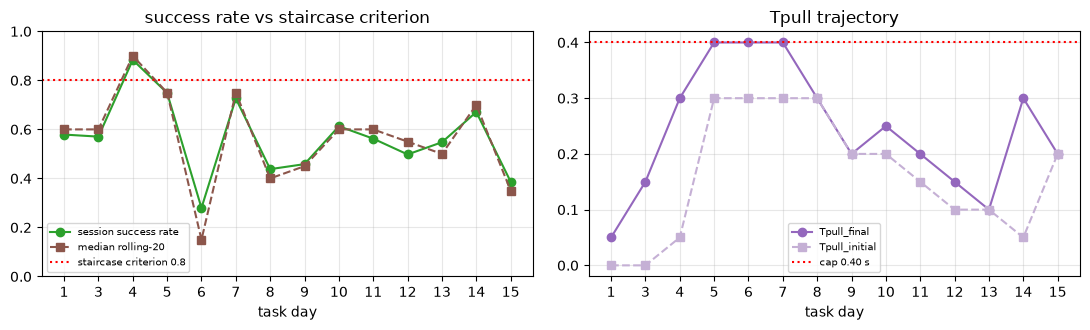

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
x = stair['day_idx']
axes[0].plot(x, stair['success_rate'], 'o-', color='#2ca02c', label='session success rate')
axes[0].plot(x, stair['roll20_median'], 's--', color='#8c564b', label='median rolling-20')
axes[0].axhline(0.8, color='r', ls=':', label='staircase criterion 0.8')
axes[0].set_ylim(0, 1); axes[0].set_title('success rate vs staircase criterion'); axes[0].legend(fontsize=7)
axes[1].plot(x, stair['Tpull_final'], 'o-', color='#9467bd', label='Tpull_final')
axes[1].plot(x, stair['Tpull_init'], 's--', color='#c5b0d5', label='Tpull_initial')
axes[1].axhline(0.4, color='r', ls=':', label='cap 0.40 s')
axes[1].set_title('Tpull trajectory'); axes[1].legend(fontsize=7)
for ax in axes:
    ax.set_xticks(x); ax.set_xticklabels(day_stats['day_num'].astype(str)); ax.set_xlabel('task day'); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 3. チェック2: Short Pull の3類型分解

[data.md](../docs/data.md)・[CLAUDE.md](../CLAUDE.md) の記述に従い、Short Pull を次の3類型に分ける。

* **引き足りない (too_short)**: 測定 `pull_duration` < `pull_duration_for_success`
* **締め切り超過 (deadline)**: 閾値ぶんは引けているが、引き始めの遅れ（`t_onset - t_start`）＋閾値 が締め切りを超える
* **接触途切れ (dropout)**: 上記いずれでもない（行動としては閾値以上引けており、課題側が接触途切れで確定させた）

締め切りはNo Reaction試行の `stop_time - start_time` の中央値から実測で決める。

In [11]:
nr_tr = tr[tr['trial_type'] == 'No Reaction']
DEADLINE = float((nr_tr['t_end'] - nr_tr['t_start']).median())
print(f'締め切り（No Reaction試行の窓長の中央値）: {DEADLINE:.4f} 秒')
print('  分布 (0/25/50/75/100%):',
      np.round(np.percentile((nr_tr['t_end'] - nr_tr['t_start']).dropna(), [0, 25, 50, 75, 100]), 4))

sp = tr[tr['trial_type'] == 'Short Pull'].copy()
sp['rt'] = sp['t_onset'] - sp['t_start']

def classify(row):
    dur, thr, rt = row['pull_duration'], row['pull_duration_for_success'], row['rt']
    if not np.isfinite(dur):
        return 'unmeasured'
    if np.isfinite(thr) and dur < thr:
        return 'too_short'
    if np.isfinite(thr) and np.isfinite(rt) and (rt + thr) > DEADLINE:
        return 'deadline'
    return 'dropout'

sp['sp_subtype'] = sp.apply(classify, axis=1)
cnt = sp['sp_subtype'].value_counts()
print()
print('Short Pull の内訳 (n=%d):' % len(sp))
for k, v in cnt.items():
    print(f'  {k:12s} {v:5d}  {v / len(sp) * 100:5.1f}%')
print()
print('day別:')
print(pd.crosstab(sp['task_day'], sp['sp_subtype']).to_string())

tr['sp_subtype'] = ''
tr.loc[sp.index, 'sp_subtype'] = sp['sp_subtype']

締め切り（No Reaction試行の窓長の中央値）: 1.0000 秒
  分布 (0/25/50/75/100%): [1.     1.     1.     1.     1.0334]

Short Pull の内訳 (n=511):
  dropout        317   62.0%
  too_short      184   36.0%
  deadline         9    1.8%
  unmeasured       1    0.2%

day別:
sp_subtype  deadline  dropout  too_short  unmeasured
task_day                                            
task-day10         3       35         11           0
task-day11         0       59         23           0
task-day12         0       48         18           1
task-day13         2       13         12           0
task-day14         0       36         11           0
task-day15         3       26         19           0
task-day3          0        8          5           0
task-day4          0        5          2           0
task-day5          0       17         11           0
task-day6          0        7         28           0
task-day7          0       14         18           0
task-day8          0       34         16           0
task-day9   

### 3.0 Short Pull の保持時間は day をまたいで伸びるか

報酬閾値 $T_{pull}$ が動くので、「Short Pull」が意味する保持時間の水準も day で変わりうる。閾値に対する相対値（`pull_duration / T_pull`）も併せて見る。

In [12]:
rows = []
for day in DAYS:
    g = tr[tr['task_day'] == day]
    sp_d = g[g['trial_type'] == 'Short Pull']
    su_d = g[g['trial_type'] == 'Success']
    thr_med = float(g['pull_duration_for_success'].median())
    ratio = (sp_d['pull_duration'] / sp_d['pull_duration_for_success']).replace([np.inf, -np.inf], np.nan)
    rows.append({
        'task_day': day,
        'Tpull_med': thr_med,
        'n_SP': len(sp_d),
        'SP_dur_med': float(sp_d['pull_duration'].median()),
        'SP_dur_ratio_med': float(ratio.median()) if ratio.notna().any() else np.nan,
        'n_Succ': len(su_d),
        'Succ_dur_med': float(su_d['pull_duration'].median()),
        'frac_dropout': float((sp_d['sp_subtype'] == 'dropout').mean()) if len(sp_d) else np.nan,
        'frac_too_short': float((sp_d['sp_subtype'] == 'too_short').mean()) if len(sp_d) else np.nan,
    })
spday = pd.DataFrame(rows)
spday['day_idx'] = np.arange(1, len(spday) + 1)
print(spday.round(3).to_string(index=False))
print()
print('day index に対する単調傾向')
for m in ['SP_dur_med', 'SP_dur_ratio_med', 'Succ_dur_med', 'frac_dropout', 'frac_too_short']:
    rho, ps, r, pp = trend(spday[m], spday['day_idx'])
    print(f'  {m:18s} Spearman {rho:+.3f} (p={ps:.3f})')
print()
print('Tpull_med に対する相関（閾値が上がると保持時間も伸びるか）')
for m in ['SP_dur_med', 'Succ_dur_med']:
    rho, ps, r, pp = trend(spday[m], spday['Tpull_med'])
    print(f'  {m:18s} Spearman {rho:+.3f} (p={ps:.3f})')

  task_day  Tpull_med  n_SP  SP_dur_med  SP_dur_ratio_med  n_Succ  Succ_dur_med  frac_dropout  frac_too_short  day_idx
 task-day1       0.00     0         NaN               NaN      44         0.933           NaN             NaN        1
 task-day3       0.05    13       0.067             1.666      89         1.067         0.615           0.385        2
 task-day4       0.15     7       0.800             3.500      91         1.467         0.714           0.286        3
 task-day5       0.40    28       0.567             1.416     137         1.367         0.607           0.393        4
 task-day6       0.40    35       0.167             0.476      89         1.267         0.200           0.800        5
 task-day7       0.40    32       0.317             0.833     114         2.100         0.438           0.562        6
 task-day8       0.30    50       0.650             2.167      67         1.667         0.680           0.320        7
 task-day9       0.20    26       0.250         

### 3.1 時間的なまとまりがあるか

HMMの状態がカテゴリの出方を説明できるためには、そのカテゴリが**系列内でまとまって出現する**必要がある（状態は持続するため）。ラベル系列のlag-1自己相関と runs test（Wald–Wolfowitz）で、独立ベルヌーイからの逸脱を測る。runs test の z は、負なら run 数が期待より少ない＝まとまりがあることを意味する。

* `yA`（反応したか）: 系統Aが説明する量。比較の基準になる。
* `Short Pull | pulled`: 系統Bが系統Aに加えて説明しようとしている量。
* `Short Pull | pulled, 接触途切れ型を除く`: 上記からセンサー由来の成分を落としたもの。

In [13]:
def runs_z(b):
    b = np.asarray(b, dtype=int)
    n = len(b); n1 = int(b.sum()); n0 = n - n1
    if n1 == 0 or n0 == 0 or n < 20:
        return np.nan
    R = 1 + int((np.diff(b) != 0).sum())
    mu = 2 * n1 * n0 / n + 1
    var = (mu - 1) * (mu - 2) / (n - 1)
    if var <= 0:
        return np.nan
    return (R - mu) / np.sqrt(var)

def lag1(b):
    b = np.asarray(b, dtype=float)
    if len(b) < 20 or b.std() == 0:
        return np.nan
    return float(np.corrcoef(b[:-1], b[1:])[0, 1])

def summarize(seq_by_day, label):
    zs, acs, ns = [], [], []
    for day, b in seq_by_day:
        z, a = runs_z(b), lag1(b)
        if np.isfinite(z): zs.append(z)
        if np.isfinite(a): acs.append(a)
        ns.append(len(b))
    zs = np.array(zs); acs = np.array(acs)
    stouffer = zs.sum() / np.sqrt(len(zs)) if len(zs) else np.nan
    p = 2 * stats.norm.sf(abs(stouffer)) if np.isfinite(stouffer) else np.nan
    print(label)
    print(f'  使用day数 {len(zs)} / 系列長 中央値 {int(np.median(ns))}')
    print(f'  lag-1 自己相関: 平均 {np.nanmean(acs):+.3f}  (day別: {np.round(acs, 2)})')
    print(f'  runs test z: 平均 {zs.mean():+.2f}  Stouffer合成 z={stouffer:+.2f}  p={p:.2e}')
    print(f'  z<-1.96 のday数（まとまりあり）: {(zs < -1.96).sum()} / {len(zs)}')
    return stouffer, float(np.nanmean(acs))

seq_yA = [(d, tr.loc[tr['task_day'] == d, 'yA'].to_numpy()) for d in DAYS]
res = {}
res['yA'] = summarize(seq_yA, 'A) yA（cueに反応したか、全音提示試行）')
print()

pulled = tr[tr['trial_type'] != 'No Reaction']
seq_sp = [(d, (pulled.loc[pulled['task_day'] == d, 'trial_type'] == 'Short Pull').astype(int).to_numpy())
          for d in DAYS]
res['short'] = summarize(seq_sp, 'B) Short Pull か（押下試行のみの部分系列）')
print()

pulled_nodrop = pulled[pulled['sp_subtype'] != 'dropout']
seq_sp2 = [(d, (pulled_nodrop.loc[pulled_nodrop['task_day'] == d, 'trial_type'] == 'Short Pull').astype(int).to_numpy())
           for d in DAYS]
res['short_nodrop'] = summarize(seq_sp2, 'C) Short Pull か（押下試行、接触途切れ型を除外）')

A) yA（cueに反応したか、全音提示試行）
  使用day数 14 / 系列長 中央値 156
  lag-1 自己相関: 平均 +0.249  (day別: [ 0.24  0.2   0.37  0.38  0.56  0.41  0.05  0.06  0.31  0.19  0.26 -0.01
  0.21  0.25])
  runs test z: 平均 -3.43  Stouffer合成 z=-12.83  p=1.07e-37
  z<-1.96 のday数（まとまりあり）: 11 / 14

B) Short Pull か（押下試行のみの部分系列）
  使用day数 13 / 系列長 中央値 120
  lag-1 自己相関: 平均 +0.047  (day別: [ 0.12 -0.08  0.31  0.16 -0.   -0.02  0.09  0.05  0.05  0.05 -0.09  0.03
 -0.06])
  runs test z: 平均 -0.65  Stouffer合成 z=-2.34  p=1.95e-02
  z<-1.96 のday数（まとまりあり）: 1 / 13

C) Short Pull か（押下試行、接触途切れ型を除外）
  使用day数 13 / 系列長 中央値 101
  lag-1 自己相関: 平均 +0.079  (day別: [ 0.15 -0.02  0.12  0.29 -0.03 -0.01  0.27  0.02 -0.02  0.14 -0.03  0.03
  0.14])
  runs test z: 平均 -0.80  Stouffer合成 z=-2.88  p=3.93e-03
  z<-1.96 のday数（まとまりあり）: 1 / 13


### 3.2 3次元入力から予測できるか

系統BがSuccess/Short Pullを分けるのに使えるのは4.2節の3次元入力だけである。その3次元から Short Pull かどうかがどれだけ予測できるかを、5-fold CVの対数損失で切片のみのモデルと比べる。改善がほぼ無ければ、状態別GLMがこの境界に与えられる説明力も限られる。

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss

def cv_gain(X, y, label, n_splits=5, seed=0):
    X = np.asarray(X, dtype=float); y = np.asarray(y, dtype=int)
    if len(np.unique(y)) < 2 or min(np.bincount(y)) < n_splits:
        print(f'{label}: サンプル不足でスキップ'); return np.nan
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    ll_m, ll_b = [], []
    for tr_i, te_i in skf.split(X, y):
        m = LogisticRegression(max_iter=2000, C=1.0)
        m.fit(X[tr_i], y[tr_i])
        ll_m.append(log_loss(y[te_i], m.predict_proba(X[te_i])[:, 1], labels=[0, 1]))
        p = np.clip(y[tr_i].mean(), 1e-6, 1 - 1e-6)
        ll_b.append(log_loss(y[te_i], np.full(len(te_i), p), labels=[0, 1]))
    gain = np.mean(ll_b) - np.mean(ll_m)
    print(label)
    print(f'  n={len(y)}  陽性率={y.mean():.3f}  切片のみ logloss={np.mean(ll_b):.4f}  '
          f'3次元入力 logloss={np.mean(ll_m):.4f}  改善={gain:+.4f}')
    return gain

feat = ['x_bias', 'x_hist_z', 'x_rew_z']
print('（Biasは定数なので実質2次元。改善は nats/試行）')
gA = cv_gain(tr[feat], tr['yA'], 'A) yA ~ 入力（全音提示試行）')
print()
gB = cv_gain(pulled[feat], (pulled['trial_type'] == 'Short Pull').astype(int),
             'B) Short Pull ~ 入力（押下試行のみ）')
print()
gC = cv_gain(pulled_nodrop[feat], (pulled_nodrop['trial_type'] == 'Short Pull').astype(int),
             'C) Short Pull ~ 入力（押下試行、接触途切れ型を除外）')

（Biasは定数なので実質2次元。改善は nats/試行）


A) yA ~ 入力（全音提示試行）
  n=2359  陽性率=0.765  切片のみ logloss=0.5456  3次元入力 logloss=0.4398  改善=+0.1058

B) Short Pull ~ 入力（押下試行のみ）
  n=1804  陽性率=0.283  切片のみ logloss=0.5960  3次元入力 logloss=0.5846  改善=+0.0114

C) Short Pull ~ 入力（押下試行、接触途切れ型を除外）
  n=1487  陽性率=0.130  切片のみ logloss=0.3873  3次元入力 logloss=0.3799  改善=+0.0074


## 4. チェック3: $P(z)\geq0.8$ の残存率と 状態×試行タイプ のday別セル数

6.1節はAloorに倣い $P(z)\geq0.8$ で状態を確定させ、6.4節はday内で状態×試行タイプの試行数を釣り合わせる。この2つを通した後にday別で何試行残るかを見積もる。

ここで使うのは**Ver.5の 5.4節 Step (1)（全day連結の静的GLM-HMM）**に相当するモデル。動的部分（$\alpha$, $\kappa$）は未実装なので、静的フィットでの残存率を目安として読む。

In [15]:
ys, xs = [], []
for d in DAYS:
    g = tr[tr['task_day'] == d]
    ys.append(g[['yA']].to_numpy(dtype=int))
    xs.append(g[INPUT_COLS].to_numpy(dtype=float))
print('sequences:', len(ys), 'trials:', sum(len(y) for y in ys), 'input dim:', xs[0].shape[1])

modelA, llsA, bestA = v4.train_glmhmm_map(
    ys, xs, num_states=NUM_STATES, prior_sigma=PRIOR_SIGMA, num_iters=NUM_ITERS, seeds=SEEDS
)
zA, pA = v4.decode_states(modelA, ys, xs)
trA = v4.attach_decoded_states(tr, zA, pA)
pcols = [c for c in trA.columns if c.startswith('p_state_')]
trA['p_max'] = trA[pcols].max(axis=1)
print()
print('最尤状態の事後確率 p_max の分布:')
print(trA['p_max'].describe().round(3))

sequences: 14 trials: 2359 input dim: 3


Training GLM-HMM K=3 M=3 prior_sigma=2.0


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 0: log_prob=-1006.11


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 1: log_prob=-1004.26


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 2: log_prob=-1006.02
Best log_prob=-1004.26

最尤状態の事後確率 p_max の分布:
count    2359.000
mean        0.927
std         0.124
min         0.493
25%         0.926
50%         0.992
75%         0.999
max         1.000
Name: p_max, dtype: float64


In [16]:
print(f'閾値 P(z)>={P_THRESHOLD} の残存率')
overall = (trA['p_max'] >= P_THRESHOLD).mean()
print(f'  全体: {overall:.3f}  ({int((trA["p_max"] >= P_THRESHOLD).sum())} / {len(trA)} 試行)')
ret = trA.groupby('task_day', sort=False)['p_max'].apply(lambda s: (s >= P_THRESHOLD).mean())
print('  day別:')
print(ret.round(3).to_string())

kept = trA[trA['p_max'] >= P_THRESHOLD]
print()
print('残存試行の 状態×試行タイプ（全day合計）:')
print(pd.crosstab(kept['state'], kept['trial_type']).to_string())

閾値 P(z)>=0.8 の残存率
  全体: 0.844  (1991 / 2359 試行)
  day別:
task_day
task-day1     1.000
task-day3     0.923
task-day4     1.000
task-day5     0.858
task-day6     0.755
task-day7     1.000
task-day8     0.797
task-day9     0.125
task-day10    0.761
task-day11    0.828
task-day12    0.927
task-day13    0.952
task-day14    0.814
task-day15    0.908

残存試行の 状態×試行タイプ（全day合計）:
trial_type  No Reaction  Short Pull  Success
state                                       
0                   258         167      399
1                   178          21       22
2                    63         232      651


In [17]:
# 6.4節のバランシング（day内で状態×試行タイプを釣り合わせる）後に何試行使えるか
rows = []
for d in DAYS:
    g = kept[kept['task_day'] == d]
    ct = pd.crosstab(g['trial_type'], g['state'])
    ct = ct.reindex(index=SOUND_TYPES, columns=range(NUM_STATES), fill_value=0)
    per_type_min = ct.min(axis=1)
    usable = int((per_type_min * NUM_STATES).sum())
    rows.append({
        'task_day': d,
        'n_all': int((trA['task_day'] == d).sum()),
        'n_kept': len(g),
        'n_states_present': int((ct.sum(axis=0) > 0).sum()),
        'min_cell': int(ct.values.min()),
        'usable_balanced': usable,
        'usable_per_state': usable // NUM_STATES,
    })
bal = pd.DataFrame(rows)
print(bal.to_string(index=False))
print()
print(f'day別 balanced 使用可能試行数: 中央値 {bal["usable_balanced"].median():.0f}, '
      f'最小 {bal["usable_balanced"].min()}, 最大 {bal["usable_balanced"].max()}')
print(f'全day合計: {bal["usable_balanced"].sum()} 試行')
print(f'min_cell=0 のday数: {(bal["min_cell"] == 0).sum()} / {len(bal)}')

  task_day  n_all  n_kept  n_states_present  min_cell  usable_balanced  usable_per_state
 task-day1     76      76                 1         0                0                 0
 task-day3    156     144                 1         0                0                 0
 task-day4    103     103                 1         0                0                 0
 task-day5    183     157                 1         0                0                 0
 task-day6    318     240                 2         0                0                 0
 task-day7    157     157                 1         0                0                 0
 task-day8    153     122                 1         0                0                 0
 task-day9     72       9                 1         0                0                 0
task-day10    155     118                 1         0                0                 0
task-day11    233     193                 1         0                0                 0
task-day12    233    

In [18]:
# 閾値をかけない状態占有（day別）。状態がday単位に分かれてしまっていないかの確認。
occ = pd.crosstab(trA['task_day'], trA['state']).reindex(DAYS)
occ_frac = occ.div(occ.sum(axis=1), axis=0)
print('day別 状態占有数（閾値なし・全試行）:')
print(occ.to_string())
print()
print('day別 状態占有率:')
print(occ_frac.round(3).to_string())
print()
n_states_day = (occ > 0).sum(axis=1)
dom = occ_frac.max(axis=1)
print('dayごとに出現した状態数:', n_states_day.to_dict())
print(f'最頻状態の占有率: 中央値 {dom.median():.3f} / 最小 {dom.min():.3f} / 最大 {dom.max():.3f}')
print(f'1状態が90%以上を占めるday: {int((dom >= 0.9).sum())} / {len(dom)}')

print()
print('状態のrun長（Viterbi系列、day内で連続する同一状態の長さ）:')
runs = []
for d in DAYS:
    z = trA.loc[trA['task_day'] == d, 'state'].to_numpy()
    if len(z) == 0:
        continue
    cut = np.flatnonzero(np.diff(z) != 0) + 1
    for seg in np.split(z, cut):
        runs.append((int(seg[0]), len(seg)))
rdf = pd.DataFrame(runs, columns=['state', 'run_len'])
print(rdf.groupby('state')['run_len'].agg(['count', 'mean', 'median', 'max']).round(2).to_string())
print(f'day内の状態切り替え回数: 合計 {len(rdf) - len(DAYS)}, day中央値 '
      f'{int(np.median([((np.diff(trA.loc[trA["task_day"] == d, "state"].to_numpy()) != 0).sum()) for d in DAYS]))}')

day別 状態占有数（閾値なし・全試行）:
state         0    1    2
task_day                 
task-day1    76    0    0
task-day3   156    0    0
task-day4     0    0  103
task-day5     0    0  183
task-day6    72  246    0
task-day7     0    0  157
task-day8   153    0    0
task-day9     0    0   72
task-day10    0    0  155
task-day11    0    0  233
task-day12  142    0   91
task-day13  126    0    0
task-day14   61    0  170
task-day15  163    0    0

day別 状態占有率:
state           0      1      2
task_day                       
task-day1   1.000  0.000  0.000
task-day3   1.000  0.000  0.000
task-day4   0.000  0.000  1.000
task-day5   0.000  0.000  1.000
task-day6   0.226  0.774  0.000
task-day7   0.000  0.000  1.000
task-day8   1.000  0.000  0.000
task-day9   0.000  0.000  1.000
task-day10  0.000  0.000  1.000
task-day11  0.000  0.000  1.000
task-day12  0.609  0.000  0.391
task-day13  1.000  0.000  0.000
task-day14  0.264  0.000  0.736
task-day15  1.000  0.000  0.000

dayごとに出現した状態数: {'task-day1': 1, 'tas

       count    mean  median  max
state                            
0          8  118.62   134.0  163
1          1  246.00   246.0  246
2          8  145.50   156.0  233
day内の状態切り替え回数: 合計 3, day中央値 0


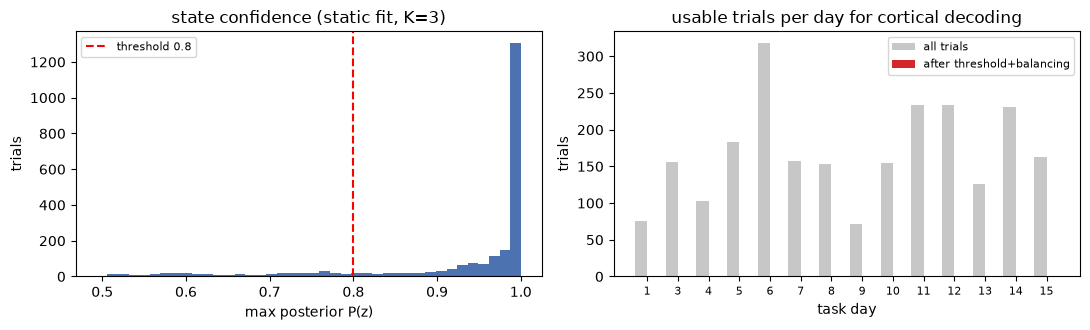

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(trA['p_max'], bins=40, color='#4c72b0')
axes[0].axvline(P_THRESHOLD, color='r', ls='--', label=f'threshold {P_THRESHOLD}')
axes[0].set_xlabel('max posterior P(z)'); axes[0].set_ylabel('trials'); axes[0].legend(fontsize=8)
axes[0].set_title('state confidence (static fit, K=%d)' % NUM_STATES)

xi = np.arange(len(bal))
axes[1].bar(xi - .2, bal['n_all'], width=.4, label='all trials', color='#c7c7c7')
axes[1].bar(xi + .2, bal['usable_balanced'], width=.4, label='after threshold+balancing', color='#d62728')
axes[1].set_xticks(xi); axes[1].set_xticklabels(day_stats['day_num'].astype(str), fontsize=8)
axes[1].set_xlabel('task day'); axes[1].set_ylabel('trials'); axes[1].legend(fontsize=8)
axes[1].set_title('usable trials per day for cortical decoding')
plt.tight_layout(); plt.show()

## 5. チェック4: `ssm` の `InputDrivenObservations(C=3)` で系統Bの静的フィットが回るか

要件5.4節の Step (1)（全day連結の静的GLM-HMM）を、系統B（3値）についても `ssm` の標準機能だけで学習できるかを確かめる。`ssm` の `InputDrivenObservations` は重み配列 `Wk` の形が `(K, C-1, M)` で、`calculate_logits()` が末尾にゼロ行を積む——つまり**最後のクラスが参照カテゴリ**。要件4.1節が参照カテゴリを No Reaction と定めているので、`yB` は Success=0 / Short Pull=1 / **No Reaction=2** と符号化する。

In [20]:
import ssm
import inspect
from ssm.observations import InputDrivenObservations
print('ssm:', ssm.__file__)
print('InputDrivenObservations signature:', inspect.signature(InputDrivenObservations.__init__))

def fit_categorical_glmhmm(ys_cat, xs_in, K, C, prior_sigma=PRIOR_SIGMA, seeds=SEEDS, num_iters=NUM_ITERS):
    best_model, best_score, best_lls = None, -np.inf, None
    M = int(xs_in[0].shape[1])
    for seed in seeds:
        np.random.seed(seed)
        m = ssm.HMM(K=K, D=1, M=M, observations='input_driven_obs',
                    observation_kwargs=dict(C=C, prior_mean=0, prior_sigma=prior_sigma),
                    transitions='standard')
        lls = m.fit(ys_cat, inputs=xs_in, method='em', num_iters=num_iters, tolerance=1e-4)
        score = float(lls[-1])
        print(f'  seed {seed}: log_prob={score:.2f}')
        if score > best_score:
            best_model, best_score, best_lls = m, score, lls
    return best_model, best_score, best_lls

ysB = [tr.loc[tr['task_day'] == d, ['yB']].to_numpy(dtype=int) for d in DAYS]
print('yB のカテゴリ内訳 (0=Success, 1=Short Pull, 2=No Reaction):', np.bincount(tr['yB']))
print()
print(f'系統B: Categorical GLM-HMM K={NUM_STATES}, C=3')
modelB, bestB, llsB = fit_categorical_glmhmm(ysB, xs, K=NUM_STATES, C=3)
print(f'best log_prob = {bestB:.2f}')
print('Wk shape (K, C-1, M):', modelB.observations.Wk.shape)

ssm: /mnt/c/Users/dmasu/braidyn-bc/.venv-wsl/lib/python3.12/site-packages/ssm/__init__.py
InputDrivenObservations signature: (self, K, D, M=0, C=2, prior_mean=0, prior_sigma=1000)
yB のカテゴリ内訳 (0=Success, 1=Short Pull, 2=No Reaction): [1293  511  555]

系統B: Categorical GLM-HMM K=3, C=3


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 0: log_prob=-2060.29


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 1: log_prob=-2059.76


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 2: log_prob=-2059.74
best log_prob = -2059.74
Wk shape (K, C-1, M): (3, 2, 3)


In [21]:
# 符号化の健全性確認: yB を2値へ潰して C=2 で学習すると、系統A（v4のBernoulli実装）と一致するはず
ys_collapsed = [(y == 2).astype(int) for y in ysB]   # No Reaction=1（最後=参照）, pulled=0
print('C=2（No Reactionを最後のクラスに置いた潰し版）')
_, best_collapsed, _ = fit_categorical_glmhmm(ys_collapsed, xs, K=NUM_STATES, C=2)
print()
print(f'系統A (v4.train_glmhmm_map, C=2)   log_prob = {bestA:.2f}')
print(f'C=2 潰し版                        log_prob = {best_collapsed:.2f}')
print(f'差 = {abs(bestA - best_collapsed):.4f}  （ラベルの入れ替えは尤度を変えないので、'
      f'一致すれば符号化とパラメータ化の対応が取れている）')

C=2（No Reactionを最後のクラスに置いた潰し版）


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 0: log_prob=-1006.11


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 1: log_prob=-1004.26


  0%|          | 0/200 [00:00<?, ?it/s]

  seed 2: log_prob=-1005.86

系統A (v4.train_glmhmm_map, C=2)   log_prob = -1004.26
C=2 潰し版                        log_prob = -1004.26
差 = 0.0009  （ラベルの入れ替えは尤度を変えないので、一致すれば符号化とパラメータ化の対応が取れている）


In [22]:
# 状態ごとのカテゴリ確率（入力を平均値に固定したときの予測分布）と、系統Bの残存率
x_mean = np.array([1.0, 0.0, 0.0])   # bias=1, z化した2列の平均=0
W = modelB.observations.Wk           # (K, C-1, M)
logits = np.concatenate([W @ x_mean, np.zeros((W.shape[0], 1))], axis=1)   # 末尾に参照カテゴリの0
probs = np.exp(logits - logits.max(axis=1, keepdims=True))
probs /= probs.sum(axis=1, keepdims=True)
print('平均入力での 状態別カテゴリ確率:')
print(pd.DataFrame(probs, columns=['Success', 'Short Pull', 'No Reaction'],
                   index=[f'state {k}' for k in range(NUM_STATES)]).round(3).to_string())

zB, pB = v4.decode_states(modelB, ysB, xs)
trB = v4.attach_decoded_states(tr, zB, pB)
pcolsB = [c for c in trB.columns if c.startswith('p_state_')]
trB['p_max'] = trB[pcolsB].max(axis=1)
print()
print(f'系統B の P(z)>={P_THRESHOLD} 残存率: {(trB["p_max"] >= P_THRESHOLD).mean():.3f} '
      f'(系統A: {(trA["p_max"] >= P_THRESHOLD).mean():.3f})')
print()
print('系統B の 状態×試行タイプ（閾値適用後、全day合計）:')
keptB = trB[trB['p_max'] >= P_THRESHOLD]
print(pd.crosstab(keptB['state'], keptB['trial_type']).to_string())

平均入力での 状態別カテゴリ確率:
         Success  Short Pull  No Reaction
state 0    0.534       0.299        0.167
state 1    0.454       0.313        0.234
state 2    0.731       0.091        0.177

系統B の P(z)>=0.8 残存率: 0.852 (系統A: 0.844)

系統B の 状態×試行タイプ（閾値適用後、全day合計）:
trial_type  No Reaction  Short Pull  Success
state                                       
0                   302         284      492
1                    88         128      175
2                   116          35      389


## 6. Dynamic GLM-HMM の実装

[requirements_ver5.md](../docs/requirements_ver5.md) 5.2〜5.4節の Dynamic GLM-HMM（Cuturela et al. 2024）を実装する。4節で使った静的モデルは、day差を表現する手段が状態変数しか無いために状態がdayラベルに退化していた。動的モデルはday別のGLM重みという受け皿を持つので、**day差が重みに吸収された結果として状態が日内の切り替えを担うようになるか**を確認するのが本節の目的（5.3節・8節Step 6の関門）。

`model_type` の3段階は公開実装（[lenca56/dynamic_glmhmm](https://github.com/lenca56/dynamic_glmhmm)）に合わせる。

* `'standard'`: 重み・遷移行列とも全day共通（$\alpha\to0,\ \kappa\to\infty$ の極限）
* `'partial'`: 重みのみday別（ガウス連鎖事前分布）、遷移行列は共通。$\alpha$ をここで選ぶ
* `'dynamic'`: 重み・遷移行列ともday別。$\kappa$ をここで選ぶ

**公開実装との差**: 重みのMステップは、公開実装がセッションを昇順に1つずつ更新する Gauss–Seidel 型なのに対し、ここでは全day・全状態の重みを1回の L-BFGS-B で同時に最適化する。式1の連鎖事前分布から導かれる罰則付きECLLをそのまま最大化しているので停留点は同じで、EM1反復あたりの最適化呼び出しが1回で済む。初期状態分布は Cuturela et al. 2024 と同じく一様固定で推定しない。

In [23]:
# -*- coding: utf-8 -*-
"""Dynamic GLM-HMM (Cuturela et al. 2024) — minimal reference implementation.

model_type:
  'standard' : weights and transition matrix shared across all days
  'partial'  : per-day weights (Gaussian chain prior), shared transition matrix
  'dynamic'  : per-day weights and per-day transition matrices (Dirichlet prior on A)
"""
import numpy as np
from scipy.optimize import minimize
from scipy.special import logsumexp


# ---------------------------------------------------------------- observation
def obs_logp(W_k, X, C):
    """log p(y=c | x, state k) for every class. W_k: (C-1, D) -> (T, C)."""
    logits = np.concatenate([X @ W_k.T, np.zeros((X.shape[0], 1))], axis=1)
    return logits - logsumexp(logits, axis=1, keepdims=True)


def _day_logits(W_s, X, C):
    """(T, K, C) logits for every state, with the last class fixed at 0."""
    T = X.shape[0]
    K = W_s.shape[0]
    logits = np.zeros((T, K, C))
    logits[:, :, :C - 1] = np.einsum('td,kcd->tkc', X, W_s)
    return logits


def day_loglik(W_s, X, y, C):
    """(T, K) matrix of log p(y_t | x_t, z_t=k)."""
    logits = _day_logits(W_s, X, C)
    lse = logsumexp(logits, axis=2)
    idx = np.broadcast_to(y[:, None, None], logits.shape[:2] + (1,))
    return np.take_along_axis(logits, idx, axis=2)[:, :, 0] - lse


# ------------------------------------------------------------ forward-backward
def forward_backward(b, P, pi):
    """Scaled forward-backward. b: (T,K) emission probabilities. Returns gamma, xi, log c."""
    T, K = b.shape
    alpha = np.empty((T, K))
    c = np.empty(T)
    a = pi * b[0]
    c[0] = a.sum()
    alpha[0] = a / c[0]
    for t in range(1, T):
        a = b[t] * (alpha[t - 1] @ P)
        c[t] = a.sum()
        alpha[t] = a / c[t]
    beta = np.empty((T, K))
    beta[T - 1] = 1.0
    for t in range(T - 2, -1, -1):
        beta[t] = (P @ (b[t + 1] * beta[t + 1])) / c[t + 1]
    gamma = alpha * beta
    gamma /= gamma.sum(axis=1, keepdims=True)
    # xi = sum_t alpha[t] (x) (b[t+1] beta[t+1] / c[t+1]) * P   (vectorised over t)
    nxt = (b[1:] * beta[1:]) / c[1:, None]
    xi = (alpha[:-1].T @ nxt) * P
    return gamma, xi, np.log(c)


# ------------------------------------------------------------------- M-step: W
def _w_objective(wflat, shape, xs, ys, gammas, C, alpha_w, sigma0, tied):
    """Negative penalised ECLL and its gradient, jointly over all days and states."""
    S_w, K, Cm1, D = shape
    W = wflat.reshape(shape)
    f = 0.0
    G = np.zeros(shape)
    for s in range(len(xs)):
        si = 0 if tied else s
        X, y, g = xs[s], ys[s], gammas[s]
        T = len(y)
        logits = _day_logits(W[si], X, C)                     # (T, K, C)
        lse = logsumexp(logits, axis=2)                       # (T, K)
        yidx = np.broadcast_to(y[:, None, None], (T, K, 1))
        f += float((g * (np.take_along_axis(logits, yidx, axis=2)[:, :, 0] - lse)).sum())
        p = np.exp(logits - lse[:, :, None])                  # (T, K, C)
        onehot = np.zeros((T, C))
        onehot[np.arange(T), y] = 1.0
        resid = (onehot[:, None, :] - p)[:, :, :Cm1]          # (T, K, C-1)
        G[si] += np.einsum('tkc,td->kcd', resid * g[:, :, None], X)
    if tied:
        f -= 0.5 * np.sum(W ** 2) / sigma0 ** 2
        G -= W / sigma0 ** 2
    else:
        f -= 0.5 * np.sum(W[0] ** 2) / sigma0 ** 2
        G[0] -= W[0] / sigma0 ** 2
        d = W[1:] - W[:-1]
        f -= 0.5 * np.sum(d ** 2) / alpha_w ** 2
        G[1:] -= d / alpha_w ** 2
        G[:-1] += d / alpha_w ** 2
    return -f, -G.ravel()


# ------------------------------------------------------------------------ fit
def fit_dyn_glmhmm(ys, xs, K, C=2, model_type='dynamic',
                   alpha_w=1.0, kappa=1.0, sigma0=2.0,
                   masks=None, W_init=None, P_init=None, A_global=None, pi_init=None,
                   fit_pi=False, num_iters=150, tol=1e-6, seed=0, verbose=False):
    """fit_pi=False fixes z_1 ~ U({1..K}) as in Cuturela et al. 2024; True estimates the
    shared initial-state distribution by EM, as ssm / Ashwood et al. 2022 do. With only a
    few short sequences this choice moves the log-likelihood by several nats."""
    S = len(ys)
    D = xs[0].shape[1]
    Cm1 = C - 1
    tied = (model_type == 'standard')
    per_day_P = (model_type == 'dynamic')
    Wshape = ((1 if tied else S), K, Cm1, D)

    rng = np.random.default_rng(seed)
    if W_init is None:
        W = rng.normal(0.0, 0.5, Wshape)
    else:
        W0 = np.asarray(W_init, dtype=float)
        if W0.ndim == 3:                                  # (K, C-1, D) -> broadcast
            W = np.repeat(W0[None], Wshape[0], axis=0)
        elif W0.shape[0] == 1 and Wshape[0] > 1:
            W = np.repeat(W0, Wshape[0], axis=0)
        elif W0.shape[0] > 1 and Wshape[0] == 1:
            W = W0.mean(axis=0, keepdims=True)
        else:
            W = W0.copy()

    if P_init is None:
        P0 = np.full((K, K), 0.5 / max(K - 1, 1))
        np.fill_diagonal(P0, 0.5)
        P0 /= P0.sum(axis=1, keepdims=True)
    else:
        P0 = np.asarray(P_init, dtype=float)
        if P0.ndim == 3:
            P0 = P0.mean(axis=0)
    P = np.repeat(P0[None], S, axis=0) if per_day_P else P0.copy()
    A = P0.copy() if A_global is None else np.asarray(A_global, dtype=float)

    pi = np.full(K, 1.0 / K) if pi_init is None else np.asarray(pi_init, dtype=float).copy()
    if masks is None:
        masks = [np.ones(len(y), bool) for y in ys]
    prior_dir = np.ones((K, K))
    np.fill_diagonal(prior_dir, 10.0)                     # sticky Dirichlet for shared P

    lps, lls = [], []
    n_iter = 0
    for it in range(num_iters):
        n_iter = it + 1
        gammas, xis, ll = [], [], 0.0
        for s in range(S):
            si = 0 if tied else s
            b = np.exp(day_loglik(W[si], xs[s], ys[s], C))
            b = np.where(masks[s][:, None], b, 1.0)
            g, x_, logc = forward_backward(b, P[s] if per_day_P else P, pi)
            gammas.append(g)
            xis.append(x_)
            ll += logc.sum()

        lp = ll
        if tied:
            lp -= 0.5 * np.sum(W ** 2) / sigma0 ** 2
        else:
            lp -= 0.5 * np.sum(W[0] ** 2) / sigma0 ** 2
            lp -= 0.5 * np.sum((W[1:] - W[:-1]) ** 2) / alpha_w ** 2
        lps.append(lp)
        lls.append(ll)
        if verbose and it % 10 == 0:
            print(f'    iter {it:3d}  log posterior {lp:.4f}')
        if it > 0 and abs(lps[-1] - lps[-2]) < tol * max(1.0, abs(lps[-2])):
            break

        res = minimize(_w_objective, W.ravel(),
                       args=(Wshape, xs, ys, gammas, C, alpha_w, sigma0, tied),
                       jac=True, method='L-BFGS-B', options=dict(maxiter=50))
        W = res.x.reshape(Wshape)

        if fit_pi:
            pi = np.sum([g[0] for g in gammas], axis=0) + 1.0   # Dirichlet(1) smoothing
            pi /= pi.sum()

        if per_day_P:
            for s in range(S):
                num = xis[s] + kappa * A
                P[s] = num / num.sum(axis=1, keepdims=True)
        else:
            num = np.maximum(np.sum(xis, axis=0) + prior_dir - 1.0, 1e-12)
            P = num / num.sum(axis=1, keepdims=True)

    A_out = P.copy() if not per_day_P else A
    return dict(W=W, P=P, pi=pi, A=A_out, lps=np.asarray(lps), lls=np.asarray(lls),
                model_type=model_type, n_iter=n_iter, fit_pi=fit_pi,
                alpha_w=alpha_w, kappa=kappa, sigma0=sigma0, K=K, C=C)


# ------------------------------------------------------------------ evaluation
def _emissions(fit, ys, xs):
    W, C = fit['W'], fit['C']
    tied = W.shape[0] == 1
    for s in range(len(ys)):
        si = 0 if tied else s
        yield s, np.exp(day_loglik(W[si], xs[s], ys[s], C))


def test_loglik(fit, ys, xs, test_masks):
    """Mean per-trial log p(y_t | y_{1:t-1}) over the held-out trials."""
    P, pi = fit['P'], fit['pi']
    per_day_P = (P.ndim == 3)
    tot, n = 0.0, 0
    for s, b in _emissions(fit, ys, xs):
        _, _, logc = forward_backward(b, P[s] if per_day_P else P, pi)
        m = test_masks[s]
        tot += float(logc[m].sum())
        n += int(m.sum())
    return tot / max(n, 1)


def decode(fit, ys, xs):
    """Posterior state probabilities and MAP state per trial, per day."""
    P, pi = fit['P'], fit['pi']
    per_day_P = (P.ndim == 3)
    gammas, zs = [], []
    for s, b in _emissions(fit, ys, xs):
        g, _, _ = forward_backward(b, P[s] if per_day_P else P, pi)
        gammas.append(g)
        zs.append(g.argmax(axis=1))
    return zs, gammas


def block_folds(T, n_folds=5, block=10, seed=0):
    """Assign each trial to a CV fold in contiguous blocks (Cuturela's split_data)."""
    n_blocks = int(np.ceil(T / block))
    rng = np.random.default_rng(seed)
    order = rng.permutation(n_blocks)
    fold_of_block = np.empty(n_blocks, dtype=int)
    fold_of_block[order] = np.arange(n_blocks) % n_folds
    return np.repeat(fold_of_block, block)[:T]

### 6.1 合成データでの検証（パラメータ復元）

実データに当てる前に、真のパラメータが分かっている合成データで復元できるかを確認する（Cuturela et al. 2024 Supplemental Figure 1 と同じ趣旨）。真の重みは $\alpha_{true}=0.30$ のランダムウォークでdayをまたいで漂流させ、14 day × 170試行を生成する。

In [24]:
from itertools import permutations

def simulate_dyn(S=14, T=170, K=2, D=3, C=2, alpha_true=0.30, seed=0):
    rng = np.random.default_rng(seed)
    Wt = np.zeros((S, K, C - 1, D))
    Wt[0, 0, 0] = [2.0, 0.5, 0.0]     # よく引く状態
    Wt[0, 1, 0] = [-1.5, 0.0, 0.0]    # 引かない状態
    for s in range(1, S):
        Wt[s] = Wt[s - 1] + rng.normal(0, alpha_true, Wt[s - 1].shape)
    Pt = np.array([[0.95, 0.05], [0.10, 0.90]])
    ys_s, xs_s, zs_s = [], [], []
    for s in range(S):
        X = np.column_stack([np.ones(T), rng.normal(0, 1, T), rng.normal(0, 1, T)])
        z = np.empty(T, dtype=int); z[0] = rng.integers(K)
        for t in range(1, T):
            z[t] = rng.choice(K, p=Pt[z[t - 1]])
        logit = np.stack([X @ Wt[s, k, 0] for k in range(K)], axis=1)[np.arange(T), z]
        pull = (rng.random(T) < 1.0 / (1.0 + np.exp(-logit))).astype(int)
        ys_s.append(1 - pull)          # クラス0=引いた, クラス1(=参照)=引かない
        xs_s.append(X); zs_s.append(z)
    return ys_s, xs_s, zs_s, Wt, Pt

def best_perm_acc(z_true, z_hat, K):
    a = np.concatenate(z_true); b = np.concatenate(z_hat)
    best, arg = -1.0, None
    for perm in permutations(range(K)):
        acc = float((np.array(perm)[b] == a).mean())
        if acc > best:
            best, arg = acc, perm
    return best, arg

sy, sx, sz, W_true, P_true = simulate_dyn()
print('合成データ: %d day × %d 試行, K=2, 真のalpha=0.30' % (len(sy), len(sy[0])))

s_std = fit_dyn_glmhmm(sy, sx, K=2, C=2, model_type='standard', sigma0=2.0, seed=0)
s_par = fit_dyn_glmhmm(sy, sx, K=2, C=2, model_type='partial', alpha_w=0.3, sigma0=2.0,
                       W_init=s_std['W'], P_init=s_std['P'], seed=0)
s_dyn = fit_dyn_glmhmm(sy, sx, K=2, C=2, model_type='dynamic', alpha_w=0.3, kappa=100.0,
                       sigma0=2.0, W_init=s_par['W'], P_init=s_par['P'], A_global=s_par['A'], seed=0)
for nm, ft in [('standard', s_std), ('partial', s_par), ('dynamic', s_dyn)]:
    zh, _ = decode(ft, sy, sx)
    acc, _ = best_perm_acc(sz, zh, 2)
    print(f'  {nm:8s} log posterior {ft["lps"][-1]:9.2f}  {ft["n_iter"]:3d} iters  状態復元 {acc:.3f}')

zh, _ = decode(s_par, sy, sx)
_, perm = best_perm_acc(sz, zh, 2)
W_hat = s_par['W'][:, np.argsort(np.array(perm))]
print(f'  partial の重み軌跡: 平均絶対誤差 {np.abs(W_hat - W_true).mean():.3f} '
      f'(真の値の範囲 {W_true.min():.2f}..{W_true.max():.2f})、'
      f'真値との相関 {np.corrcoef(W_true.ravel(), W_hat.ravel())[0, 1]:.3f}')

合成データ: 14 day × 170 試行, K=2, 真のalpha=0.30


  standard log posterior  -1291.37   48 iters  状態復元 0.931
  partial  log posterior  -1251.39    9 iters  状態復元 0.937
  dynamic  log posterior  -1247.59   11 iters  状態復元 0.937
  partial の重み軌跡: 平均絶対誤差 0.222 (真の値の範囲 -2.78..2.83)、真値との相関 0.982


In [25]:
# 合成データでのalphaグリッド（真値0.30が選ばれるか）
sfolds = [block_folds(len(y), n_folds=5, block=10, seed=0) for y in sy]
print('合成データ 5-fold CV（model_type="partial"）')
for a in [0.01, 0.1, 0.3, 1.0, 10.0]:
    sc = []
    for f in range(5):
        fit = fit_dyn_glmhmm(sy, sx, K=2, C=2, model_type='partial', alpha_w=a, sigma0=2.0,
                             masks=[fo != f for fo in sfolds],
                             W_init=s_std['W'], P_init=s_std['P'], num_iters=80, seed=0)
        sc.append(test_loglik(fit, sy, sx, [fo == f for fo in sfolds]))
    print(f'  alpha={a:6.2f}  test LL/試行 {np.mean(sc):+.4f}  SE {np.std(sc)/np.sqrt(len(sc)):.4f}')
print('真のalphaは0.30。alpha=0.01（ほぼ静的）が明確に劣ることが確認できればよい。')

合成データ 5-fold CV（model_type="partial"）


  alpha=  0.01  test LL/試行 -0.5546  SE 0.0062


  alpha=  0.10  test LL/試行 -0.5451  SE 0.0068


  alpha=  0.30  test LL/試行 -0.5369  SE 0.0068


  alpha=  1.00  test LL/試行 -0.5329  SE 0.0066


  alpha= 10.00  test LL/試行 -0.5333  SE 0.0063
真のalphaは0.30。alpha=0.01（ほぼ静的）が明確に劣ることが確認できればよい。


### 6.2 実データへの3段階フィット

系統A（$y^A$）で実行する。参照カテゴリを No Reaction に置くため、`y_dyn = 1` を No Reaction、`y_dyn = 0` を押下ありと符号化する（重みは「引く」側の対数オッズを表す）。

$\alpha$ と $\kappa$ は5.5節の手順どおり、`'partial'` 段階 → `'dynamic'` 段階の順に、それぞれ5-fold CVのtest log-likelihoodで選ぶ。CVの分割はday内の連続10試行ブロックをシャッフルして5分割し、test試行は系列から除かずマスクとして渡す。

In [26]:
ys_dyn = [(tr.loc[tr['task_day'] == d, 'trial_type'] == 'No Reaction').astype(int).to_numpy()
          for d in DAYS]
xs_dyn = [tr.loc[tr['task_day'] == d, INPUT_COLS].to_numpy(dtype=float) for d in DAYS]
folds = [block_folds(len(y), n_folds=5, block=10, seed=0) for y in ys_dyn]
print('系列:', len(ys_dyn), 'day /', sum(len(y) for y in ys_dyn), '試行')
print('y_dyn の内訳 (0=押下あり, 1=No Reaction):', np.bincount(np.concatenate(ys_dyn)))
print('foldごとのtest試行数:', [int(sum((fo == f).sum() for fo in folds)) for f in range(5)])

# Step (1) の 'standard' 段は要件5.4節どおり ssm に任せ、その最良解を動的段の初期値にする。
# 自前実装の 'standard' は ssm より悪い局所解に落ちることがあるため（下の検証セル参照）。
# グリッドサーチは時間がかかるので、data/cache/ver5_dyn_fits.pkl があればそこから読む。
DYN_CACHE = CACHE_DIR / 'ver5_dyn_fits.pkl'
DYN = pd.read_pickle(DYN_CACHE) if DYN_CACHE.exists() else {}
print('キャッシュ済みの結果:', sorted(DYN) if DYN else '(なし。すべて計算する)')

t0 = time.time()
if 'ssm_std' in DYN:
    W_SSM, P_SSM = DYN['ssm_std']['W'], DYN['ssm_std']['P']
    PI_SSM, LL_SSM = DYN['ssm_std']['pi'], DYN['ssm_std']['ll']
    best_lp = DYN['ssm_std']['log_prob']
else:
  best_lp, ssm_std = -np.inf, None
  for sd in range(20):
    np.random.seed(sd)
    m = ssm.HMM(K=NUM_STATES, D=1, M=len(INPUT_COLS), observations='input_driven_obs',
                observation_kwargs=dict(C=2, prior_mean=0, prior_sigma=PRIOR_SIGMA),
                transitions='standard')
    lp = float(m.fit([y[:, None] for y in ys_dyn], inputs=xs_dyn, method='em',
                     num_iters=200, tolerance=1e-4)[-1])
    if lp > best_lp:
        best_lp, ssm_std = lp, m
  LL_SSM = float(ssm_std.log_likelihood([y[:, None] for y in ys_dyn], inputs=xs_dyn))
  W_SSM = np.array(ssm_std.observations.Wk)
  P_SSM = np.array(ssm_std.transitions.transition_matrix)
  PI_SSM = np.exp(np.array(ssm_std.init_state_distn.log_initial_state_distn))
print(f'ssm standard (20 seeds): log_prob {best_lp:.2f} / data log-likelihood {LL_SSM:.2f}'
      f'  ({time.time() - t0:.1f}s)')
print('  推定された初期状態分布 pi:', np.round(PI_SSM, 3))
print('  遷移行列の対角:', np.round(np.diag(P_SSM), 4))

系列: 14 day / 2359 試行
y_dyn の内訳 (0=押下あり, 1=No Reaction): [1804  555]
foldごとのtest試行数: [537, 508, 464, 430, 420]
キャッシュ済みの結果: ['alpha_cv', 'k_cv', 'kappa_cv', 'par_fit', 'sc_std', 'ssm_std']
ssm standard (20 seeds): log_prob -1004.26 / data log-likelihood -988.71  (0.0s)
  推定された初期状態分布 pi: [0.251 0.    0.749]
  遷移行列の対角: [0.9983 1.     0.994 ]


In [27]:
ALPHA_GRID = [0.01, 0.1, 1.0, 10.0, 100.0]
t0 = time.time()
if 'alpha_cv' in DYN:
    alpha_cv = DYN['alpha_cv']
    print('[cache] alpha グリッド')
else:
  rows = []
  prev_W, prev_P = W_SSM, P_SSM
  for a in ALPHA_GRID:
    sc = []
    for f in range(5):
        ft = fit_dyn_glmhmm(ys_dyn, xs_dyn, K=NUM_STATES, C=2, model_type='partial',
                            alpha_w=a, sigma0=PRIOR_SIGMA,
                            masks=[fo != f for fo in folds], pi_init=PI_SSM, fit_pi=True,
                            W_init=prev_W, P_init=prev_P, num_iters=60, seed=0)
        sc.append(test_loglik(ft, ys_dyn, xs_dyn, [fo == f for fo in folds]))
    full = fit_dyn_glmhmm(ys_dyn, xs_dyn, K=NUM_STATES, C=2, model_type='partial',
                          alpha_w=a, sigma0=PRIOR_SIGMA, pi_init=PI_SSM, fit_pi=True,
                          W_init=prev_W, P_init=prev_P, seed=0)
    prev_W, prev_P = full['W'], full['P']      # 温スタート
    rows.append({'alpha': a, 'test_ll': np.mean(sc), 'se': np.std(sc) / np.sqrt(len(sc))})
    print(f'  alpha={a:7.2f}  test LL/試行 {np.mean(sc):+.4f}  SE {rows[-1]["se"]:.4f}')
  alpha_cv = pd.DataFrame(rows)
print(alpha_cv.round(4).to_string(index=False))
ALPHA_BEST = float(alpha_cv.loc[alpha_cv['test_ll'].idxmax(), 'alpha'])
print(f'選ばれた alpha = {ALPHA_BEST}  ({time.time() - t0:.1f}s)')
if ALPHA_BEST in (ALPHA_GRID[0], ALPHA_GRID[-1]):
    print('警告: alphaがグリッドの端。5.2節のとおり、端に張り付く場合はモデルが'
          '静的側またはday独立フィット側へ退化している可能性がある。')

[cache] alpha グリッド
 alpha  test_ll     se
  0.01  -0.4202 0.0086
  0.10  -0.4161 0.0086
  1.00  -0.3957 0.0089
 10.00  -0.3849 0.0099
100.00  -0.3791 0.0096
選ばれた alpha = 100.0  (0.0s)
警告: alphaがグリッドの端。5.2節のとおり、端に張り付く場合はモデルが静的側またはday独立フィット側へ退化している可能性がある。


In [28]:
par_fit = fit_dyn_glmhmm(ys_dyn, xs_dyn, K=NUM_STATES, C=2, model_type='partial',
                         alpha_w=ALPHA_BEST, sigma0=PRIOR_SIGMA, pi_init=PI_SSM, fit_pi=True,
                         W_init=W_SSM, P_init=P_SSM, seed=0)
KAPPA_GRID = [10000.0, 1000.0, 100.0, 10.0, 1.0]
t0 = time.time()
if 'kappa_cv' in DYN:
    kappa_cv = DYN['kappa_cv']
    print('[cache] kappa グリッド')
else:
  rows = []
  prev_W, prev_P = par_fit['W'], par_fit['P']
  for kp in KAPPA_GRID:
    sc = []
    for f in range(5):
        ft = fit_dyn_glmhmm(ys_dyn, xs_dyn, K=NUM_STATES, C=2, model_type='dynamic',
                            alpha_w=ALPHA_BEST, kappa=kp, sigma0=PRIOR_SIGMA,
                            masks=[fo != f for fo in folds], pi_init=par_fit['pi'], fit_pi=True,
                            W_init=prev_W, P_init=prev_P, A_global=par_fit['A'],
                            num_iters=60, seed=0)
        sc.append(test_loglik(ft, ys_dyn, xs_dyn, [fo == f for fo in folds]))
    full = fit_dyn_glmhmm(ys_dyn, xs_dyn, K=NUM_STATES, C=2, model_type='dynamic',
                          alpha_w=ALPHA_BEST, kappa=kp, sigma0=PRIOR_SIGMA,
                          pi_init=par_fit['pi'], fit_pi=True,
                          W_init=prev_W, P_init=prev_P, A_global=par_fit['A'], seed=0)
    prev_W, prev_P = full['W'], full['P']
    rows.append({'kappa': kp, 'test_ll': np.mean(sc), 'se': np.std(sc) / np.sqrt(len(sc))})
    print(f'  kappa={kp:9.1f}  test LL/試行 {np.mean(sc):+.4f}  SE {rows[-1]["se"]:.4f}')
  kappa_cv = pd.DataFrame(rows)
print(kappa_cv.round(4).to_string(index=False))
KAPPA_BEST = float(kappa_cv.loc[kappa_cv['test_ll'].idxmax(), 'kappa'])
print(f'選ばれた kappa = {KAPPA_BEST}  ({time.time() - t0:.1f}s)')

[cache] kappa グリッド
  kappa  test_ll     se
10000.0  -0.3798 0.0094
 1000.0  -0.3798 0.0093
  100.0  -0.3798 0.0093
   10.0  -0.3832 0.0104
    1.0  -0.3840 0.0095
選ばれた kappa = 1000.0  (0.0s)


[cache] standard baseline CV
standard              test LL/試行 -0.4203  SE 0.0086
partial (alpha=100.0)  test LL/試行 -0.3791
dynamic (kappa=1000.0)  test LL/試行 -0.3798


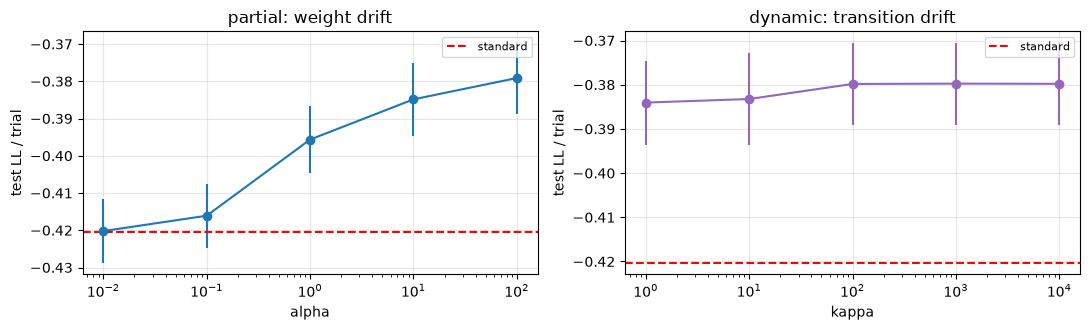

In [29]:
# 静的モデルとのhold-out比較（同じfold・同じ評価量で）
if 'sc_std' in DYN:
    sc_std = DYN['sc_std']
    print('[cache] standard baseline CV')
else:
  sc_std = []
  for f in range(5):
    ft = fit_dyn_glmhmm(ys_dyn, xs_dyn, K=NUM_STATES, C=2, model_type='standard',
                        sigma0=PRIOR_SIGMA, masks=[fo != f for fo in folds],
                        pi_init=PI_SSM, fit_pi=True, W_init=W_SSM, P_init=P_SSM,
                        num_iters=100, seed=0)
    sc_std.append(test_loglik(ft, ys_dyn, xs_dyn, [fo == f for fo in folds]))
print(f'standard              test LL/試行 {np.mean(sc_std):+.4f}  SE {np.std(sc_std)/np.sqrt(5):.4f}')
print(f'partial (alpha={ALPHA_BEST})  test LL/試行 '
      f'{alpha_cv["test_ll"].max():+.4f}')
print(f'dynamic (kappa={KAPPA_BEST})  test LL/試行 {kappa_cv["test_ll"].max():+.4f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].errorbar(alpha_cv['alpha'], alpha_cv['test_ll'], yerr=alpha_cv['se'], marker='o')
axes[0].axhline(np.mean(sc_std), color='r', ls='--', label='standard')
axes[0].set_xscale('log'); axes[0].set_xlabel('alpha'); axes[0].set_ylabel('test LL / trial')
axes[0].set_title("partial: weight drift"); axes[0].legend(fontsize=8); axes[0].grid(alpha=.3)
axes[1].errorbar(kappa_cv['kappa'], kappa_cv['test_ll'], yerr=kappa_cv['se'], marker='o', color='#9467bd')
axes[1].axhline(np.mean(sc_std), color='r', ls='--', label='standard')
axes[1].set_xscale('log'); axes[1].set_xlabel('kappa'); axes[1].set_ylabel('test LL / trial')
axes[1].set_title('dynamic: transition drift'); axes[1].legend(fontsize=8); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

#### 実装の検証と、初期状態分布の扱い

同じパラメータを与えたときに `ssm` と自前実装が同じ対数尤度を返すかを確認する。あわせて、**初期状態分布 $\pi$ の扱いが結果を大きく動かす**点を明示する。Cuturela et al. 2024 は $z_1^s \sim U(\{1,\dots,K\})$ と固定するが、`ssm`（Ashwood et al. 2022 系）は $\pi$ を推定する。dayが14本しかなく1本が100〜300試行なので、この違いは数nats効く。

In [30]:
tot = 0.0
for s in range(len(DAYS)):
    b = np.exp(day_loglik(W_SSM, xs_dyn[s], ys_dyn[s], 2))
    _, _, logc = forward_backward(b, P_SSM, PI_SSM)
    tot += logc.sum()
print(f'ssm の data log-likelihood        : {LL_SSM:.3f}')
print(f'同じパラメータを自前実装で評価    : {tot:.3f}   (差 {abs(tot - LL_SSM):.2e})')

tot_u = 0.0
for s in range(len(DAYS)):
    b = np.exp(day_loglik(W_SSM, xs_dyn[s], ys_dyn[s], 2))
    _, _, logc = forward_backward(b, P_SSM, np.full(NUM_STATES, 1.0 / NUM_STATES))
    tot_u += logc.sum()
print(f'同じパラメータ・一様pi（Cuturela式）: {tot_u:.3f}   (推定piとの差 {LL_SSM - tot_u:.3f} nats)')
print()
print('日ごとに状態がほぼ固定される解では、各dayがどの状態で始まるかを pi が担うため、'
      'pi を一様に固定すると同じ解が数nats不利になる。以降は ssm と同じく pi を推定する'
      '（fit_pi=True）。一様piに固定した場合の感度は 6.3 節で併せて報告する。')

ssm の data log-likelihood        : -988.707
同じパラメータを自前実装で評価    : -988.707   (差 1.14e-13)
同じパラメータ・一様pi（Cuturela式）: -995.529   (推定piとの差 6.822 nats)

日ごとに状態がほぼ固定される解では、各dayがどの状態で始まるかを pi が担うため、pi を一様に固定すると同じ解が数nats不利になる。以降は ssm と同じく pi を推定する（fit_pi=True）。一様piに固定した場合の感度は 6.3 節で併せて報告する。


### 6.3 日内の状態切り替えが生じるか（8節Step 6の関門）

4節で確認したとおり、静的フィットでは1状態が90%以上を占めるdayが11/14、day内の状態切り替えは全期間で3回しかなかった。動的フィットで同じ量を測る。

In [31]:
dyn_fit = fit_dyn_glmhmm(ys_dyn, xs_dyn, K=NUM_STATES, C=2, model_type='dynamic',
                         alpha_w=ALPHA_BEST, kappa=KAPPA_BEST, sigma0=PRIOR_SIGMA,
                         pi_init=par_fit['pi'], fit_pi=True,
                         W_init=par_fit['W'], P_init=par_fit['P'], A_global=par_fit['A'], seed=0)
std_fit = fit_dyn_glmhmm(ys_dyn, xs_dyn, K=NUM_STATES, C=2, model_type='standard',
                         sigma0=PRIOR_SIGMA, pi_init=PI_SSM, fit_pi=True,
                         W_init=W_SSM, P_init=P_SSM, seed=0)
print(f'standard（ssm解を引き継いだもの）: data LL {std_fit["lls"][-1]:.2f}  '
      f'(ssm 単体 {LL_SSM:.2f})')
print(f'dynamic 最終フィット: log posterior {dyn_fit["lps"][-1]:.2f} / '
      f'data LL {dyn_fit["lls"][-1]:.2f} / {dyn_fit["n_iter"]} iters')

def state_summary(fit, label):
    zs_, gs_ = decode(fit, ys_dyn, xs_dyn)
    occ = np.zeros((len(DAYS), fit['K']))
    switches, runs, pmax = [], [], []
    for i, (z, g) in enumerate(zip(zs_, gs_)):
        for k in range(fit['K']):
            occ[i, k] = (z == k).mean()
        sw = int((np.diff(z) != 0).sum())
        switches.append(sw)
        cut = np.flatnonzero(np.diff(z) != 0) + 1
        runs += [len(seg) for seg in np.split(z, cut)]
        pmax.append(g.max(axis=1))
    dom = occ.max(axis=1)
    pmax = np.concatenate(pmax)
    print(f'\n[{label}]')
    print(f'  1状態が90%以上のday: {int((dom >= 0.9).sum())} / {len(DAYS)}'
          f'  (最頻状態占有率の中央値 {np.median(dom):.3f})')
    print(f'  day内の状態切り替え: 合計 {sum(switches)} 回 / day中央値 {int(np.median(switches))}')
    print(f'  state run長: 中央値 {int(np.median(runs))} 試行 / 最大 {max(runs)}')
    print(f'  p_max: 平均 {pmax.mean():.3f} / P(z)>={P_THRESHOLD} 残存率 {(pmax >= P_THRESHOLD).mean():.3f}')
    return dict(z=zs_, g=gs_, occ=occ, switches=np.array(switches),
                runs=np.array(runs), pmax=pmax, dom=dom)

sm_std = state_summary(std_fit, 'standard（ssm解 = 4節の静的モデル）')
sm_par = state_summary(par_fit, f'partial (alpha={ALPHA_BEST})')
sm_dyn = state_summary(dyn_fit, f'dynamic (alpha={ALPHA_BEST}, kappa={KAPPA_BEST})')

standard（ssm解を引き継いだもの）: data LL -989.61  (ssm 単体 -988.71)
dynamic 最終フィット: log posterior -892.63 / data LL -889.85 / 5 iters

[standard（ssm解 = 4節の静的モデル）]
  1状態が90%以上のday: 8 / 14  (最頻状態占有率の中央値 0.981)
  day内の状態切り替え: 合計 8 回 / day中央値 0
  state run長: 中央値 104 試行 / 最大 242
  p_max: 平均 0.927 / P(z)>=0.8 残存率 0.844

[partial (alpha=100.0)]
  1状態が90%以上のday: 0 / 14  (最頻状態占有率の中央値 0.618)
  day内の状態切り替え: 合計 28 回 / day中央値 2
  state run長: 中央値 48 試行 / 最大 205
  p_max: 平均 0.881 / P(z)>=0.8 残存率 0.724

[dynamic (alpha=100.0, kappa=1000.0)]
  1状態が90%以上のday: 0 / 14  (最頻状態占有率の中央値 0.613)
  day内の状態切り替え: 合計 28 回 / day中央値 2
  state run長: 中央値 48 試行 / 最大 205
  p_max: 平均 0.881 / P(z)>=0.8 残存率 0.723


dynamic フィットの day別 状態占有率:
            state 0  state 1  state 2  switches
task-day1     0.697    0.118    0.184         2
task-day3     0.429    0.436    0.135         2
task-day4     0.592    0.146    0.262         2
task-day5     0.290    0.645    0.066         2
task-day6     0.302    0.585    0.113         2
task-day7     0.376    0.420    0.204         2
task-day8     0.183    0.634    0.183         2
task-day9     0.847    0.042    0.111         2
task-day10    0.645    0.039    0.316         2
task-day11    0.880    0.052    0.069         2
task-day12    0.386    0.489    0.124         2
task-day13    0.452    0.373    0.175         2
task-day14    0.186    0.489    0.325         2
task-day15    0.693    0.184    0.123         2


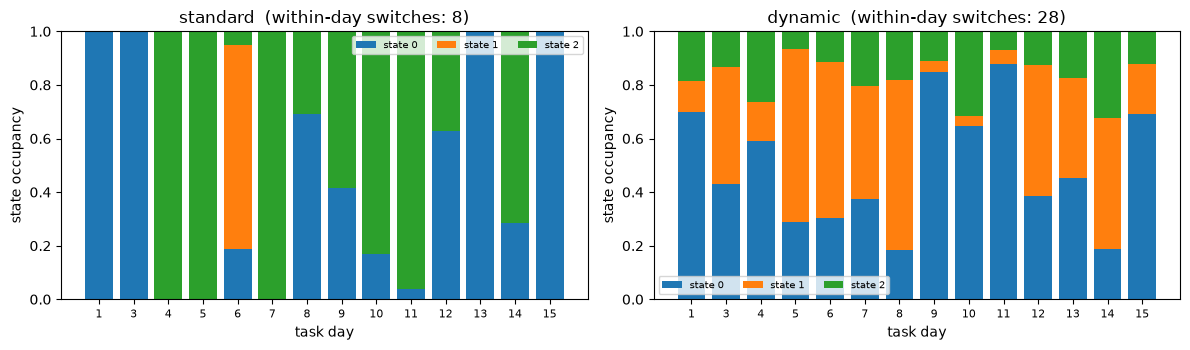

In [32]:
print('dynamic フィットの day別 状態占有率:')
occ_df = pd.DataFrame(sm_dyn['occ'], index=DAYS,
                      columns=[f'state {k}' for k in range(NUM_STATES)])
occ_df['switches'] = sm_dyn['switches']
print(occ_df.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, sm, ttl in [(axes[0], sm_std, 'standard'), (axes[1], sm_dyn, 'dynamic')]:
    bottom = np.zeros(len(DAYS))
    for k in range(NUM_STATES):
        ax.bar(np.arange(len(DAYS)), sm['occ'][:, k], bottom=bottom, label=f'state {k}')
        bottom += sm['occ'][:, k]
    ax.set_xticks(np.arange(len(DAYS)))
    ax.set_xticklabels(day_stats['day_num'].astype(str), fontsize=8)
    ax.set_xlabel('task day'); ax.set_ylabel('state occupancy'); ax.set_ylim(0, 1)
    ax.set_title(f'{ttl}  (within-day switches: {sm["switches"].sum()})')
    ax.legend(fontsize=7, ncol=NUM_STATES)
plt.tight_layout(); plt.show()

In [33]:
# 感度確認: 初期状態分布を一様に固定（Cuturela式）した場合
par_u = fit_dyn_glmhmm(ys_dyn, xs_dyn, K=NUM_STATES, C=2, model_type='partial',
                       alpha_w=ALPHA_BEST, sigma0=PRIOR_SIGMA, fit_pi=False,
                       W_init=W_SSM, P_init=P_SSM, seed=0)
dyn_u = fit_dyn_glmhmm(ys_dyn, xs_dyn, K=NUM_STATES, C=2, model_type='dynamic',
                       alpha_w=ALPHA_BEST, kappa=KAPPA_BEST, sigma0=PRIOR_SIGMA, fit_pi=False,
                       W_init=par_u['W'], P_init=par_u['P'], A_global=par_u['A'], seed=0)
sm_par_u = state_summary(par_u, 'partial（一様pi固定、Cuturela式）')
sm_dyn_u = state_summary(dyn_u, 'dynamic（一様pi固定、Cuturela式）')
print()
print('pi の扱いによる data log-likelihood の差:')
print(f'  partial: 推定pi {par_fit["lls"][-1]:.2f} vs 一様pi {par_u["lls"][-1]:.2f}')
print(f'  dynamic: 推定pi {dyn_fit["lls"][-1]:.2f} vs 一様pi {dyn_u["lls"][-1]:.2f}')


[partial（一様pi固定、Cuturela式）]
  1状態が90%以上のday: 0 / 14  (最頻状態占有率の中央値 0.575)
  day内の状態切り替え: 合計 28 回 / day中央値 2
  state run長: 中央値 44 試行 / 最大 240
  p_max: 平均 0.840 / P(z)>=0.8 残存率 0.638

[dynamic（一様pi固定、Cuturela式）]
  1状態が90%以上のday: 0 / 14  (最頻状態占有率の中央値 0.575)
  day内の状態切り替え: 合計 28 回 / day中央値 2
  state run長: 中央値 43 試行 / 最大 241
  p_max: 平均 0.840 / P(z)>=0.8 残存率 0.639

pi の扱いによる data log-likelihood の差:
  partial: 推定pi -890.27 vs 一様pi -910.52
  dynamic: 推定pi -889.85 vs 一様pi -910.13


### 6.4 皮質デコードの試行数（動的フィットの状態で再評価）

4節と同じ手続き（$P(z)\geq0.8$ で状態を確定 → day内で状態×試行タイプを釣り合わせ）を、動的フィットの状態に対して実行する。ここで使用可能試行が0を脱するかどうかが、6節（皮質デコード）に進めるかの判断材料になる。

In [34]:
def balancing_table(sm, label):
    z_all = np.concatenate(sm['z'])
    keep = sm['pmax'] >= P_THRESHOLD
    t2 = tr.copy()
    t2['state_dyn'] = z_all
    t2['p_max_dyn'] = sm['pmax']
    kept2 = t2[keep]
    rows = []
    for d in DAYS:
        g = kept2[kept2['task_day'] == d]
        ct = pd.crosstab(g['trial_type'], g['state_dyn'])
        ct = ct.reindex(index=SOUND_TYPES, columns=range(NUM_STATES), fill_value=0)
        usable = int((ct.min(axis=1) * NUM_STATES).sum())
        rows.append({'task_day': d, 'n_kept': len(g), 'min_cell': int(ct.values.min()),
                     'usable_balanced': usable})
    bt = pd.DataFrame(rows)
    print(f'[{label}] 残存率 {keep.mean():.3f}')
    print(bt.to_string(index=False))
    print(f'  balanced 使用可能試行: 中央値 {bt["usable_balanced"].median():.0f} / '
          f'全day計 {bt["usable_balanced"].sum()} / min_cell=0 のday {int((bt["min_cell"] == 0).sum())}/{len(bt)}')
    print()
    return bt, t2

bal_dyn, tr_dyn = balancing_table(sm_dyn, f'dynamic (alpha={ALPHA_BEST}, kappa={KAPPA_BEST})')
print('dynamic の 状態×試行タイプ（閾値適用後、全day合計）:')
print(pd.crosstab(tr_dyn.loc[sm_dyn['pmax'] >= P_THRESHOLD, 'state_dyn'],
                  tr_dyn.loc[sm_dyn['pmax'] >= P_THRESHOLD, 'trial_type']).to_string())

[dynamic (alpha=100.0, kappa=1000.0)] 残存率 0.723
  task_day  n_kept  min_cell  usable_balanced
 task-day1      50         0                0
 task-day3     136         0               33
 task-day4      39         0                0
 task-day5     174         0               27
 task-day6     204         3               33
 task-day7      42         0                0
 task-day8     142         3               60
 task-day9      23         0                0
task-day10     122         0                0
task-day11     221         1               12
task-day12     209         4               78
task-day13       8         0                0
task-day14     212         1               93
task-day15     123         3               36
  balanced 使用可能試行: 中央値 20 / 全day計 372 / min_cell=0 のday 8/14

dynamic の 状態×試行タイプ（閾値適用後、全day合計）:
trial_type  No Reaction  Short Pull  Success
state_dyn                                   
0                   116         189      413
1                   249        

### 6.5 状態数 $K$ の選択

5.3節が求めている、held-out尤度による $K$ の選択。`'dynamic'` 段階で $K\in\{1,\dots,5\}$ を比較する（$\alpha$・$\kappa$ は上で選んだ値に固定）。

[cache] K グリッド
 K  test_ll     se
 1  -0.4048 0.0073
 2  -0.3926 0.0085
 3  -0.3838 0.0099
 4  -0.3776 0.0113
 5  -0.3818 0.0099
選ばれた K = 4  (0.0s)


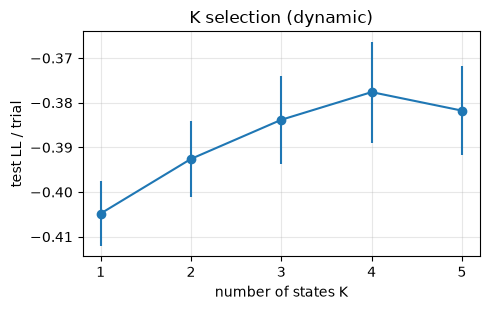

In [35]:
t0 = time.time()
if 'k_cv' in DYN:
    k_cv = DYN['k_cv']
    print('[cache] K グリッド')
else:
  rows = []
  for Kk in [1, 2, 3, 4, 5]:
    sc = []
    for f in range(5):
        np.random.seed(0)
        mk = ssm.HMM(K=Kk, D=1, M=len(INPUT_COLS), observations='input_driven_obs',
                     observation_kwargs=dict(C=2, prior_mean=0, prior_sigma=PRIOR_SIGMA),
                     transitions='standard')
        mk.fit([y[:, None] for y in ys_dyn], inputs=xs_dyn, method='em',
               num_iters=150, tolerance=1e-4)
        st = dict(W=np.array(mk.observations.Wk), P=np.array(mk.transitions.transition_matrix),
                  pi=np.exp(np.array(mk.init_state_distn.log_initial_state_distn)))
        pa = fit_dyn_glmhmm(ys_dyn, xs_dyn, K=Kk, C=2, model_type='partial',
                            alpha_w=ALPHA_BEST, sigma0=PRIOR_SIGMA,
                            masks=[fo != f for fo in folds], pi_init=st['pi'], fit_pi=True,
                            W_init=st['W'], P_init=st['P'], num_iters=60, seed=0)
        dy = fit_dyn_glmhmm(ys_dyn, xs_dyn, K=Kk, C=2, model_type='dynamic',
                            alpha_w=ALPHA_BEST, kappa=KAPPA_BEST, sigma0=PRIOR_SIGMA,
                            masks=[fo != f for fo in folds], pi_init=pa['pi'], fit_pi=True,
                            W_init=pa['W'], P_init=pa['P'], A_global=pa['A'],
                            num_iters=60, seed=0)
        sc.append(test_loglik(dy, ys_dyn, xs_dyn, [fo == f for fo in folds]))
    rows.append({'K': Kk, 'test_ll': np.mean(sc), 'se': np.std(sc) / np.sqrt(len(sc))})
    print(f'  K={Kk}  test LL/試行 {np.mean(sc):+.4f}  SE {rows[-1]["se"]:.4f}')
  k_cv = pd.DataFrame(rows)
print(k_cv.round(4).to_string(index=False))
K_BEST = int(k_cv.loc[k_cv['test_ll'].idxmax(), 'K'])
print(f'選ばれた K = {K_BEST}  ({time.time() - t0:.1f}s)')

plt.figure(figsize=(5, 3.2))
plt.errorbar(k_cv['K'], k_cv['test_ll'], yerr=k_cv['se'], marker='o')
plt.xlabel('number of states K'); plt.ylabel('test LL / trial')
plt.title('K selection (dynamic)'); plt.grid(alpha=.3); plt.xticks(k_cv['K'])
plt.tight_layout(); plt.show()

## 7. まとめ

In [36]:
print('=' * 74)
print('Ver.5 実装前チェック まとめ  mouse=%s  days=%d  音提示試行=%d' % (MOUSE_ID, len(DAYS), len(tr)))
print('=' * 74)

rho_nr, p_nr, _, _ = trend(day_stats['p_no_reaction'], day_stats['day_idx'])
rho_sc, p_sc, _, _ = trend(day_stats['p_success_all'], day_stats['day_idx'])
rho_sg, p_sg, _, _ = trend(day_stats['p_success_given_pull'], day_stats['day_idx'])
rho_th, p_th, _, _ = trend(day_stats['thr_median'], day_stats['day_idx'])
print('[1] 学習曲線 (day index に対する Spearman rho, p)')
print(f'    No Reaction率           {rho_nr:+.3f} (p={p_nr:.3f})')
print(f'    Success率(全試行)        {rho_sc:+.3f} (p={p_sc:.3f})')
print(f'    Success率(押下試行内)     {rho_sg:+.3f} (p={p_sg:.3f})')
print(f'    報酬閾値(中央値)          {rho_th:+.3f} (p={p_th:.3f})')
print(f'    隣接day間のNo Reaction率変化: 平均 {np.abs(np.diff(dnr)).mean():.3f} / 最大 {np.abs(np.diff(dnr)).max():.3f}')
rho_tf, p_tf, _, _ = trend(stair['Tpull_final'], stair['day_idx'])
print(f'    Tpull_final              {rho_tf:+.3f} (p={p_tf:.3f})  推移 '
      f'{[f"{v:.2f}" for v in stair["Tpull_final"]]}')
print(f'    実測の成功率: day中央値 {stair["success_rate"].median():.3f} '
      f'（20試行移動窓が0.8以上だった割合 {stair["frac_roll20_ge80"].mean():.3f}）')

print()
print('[2] Short Pull の内訳と時間的まとまり')
for k, v in cnt.items():
    print(f'    {k:12s} {v:5d} ({v / len(sp) * 100:5.1f}%)')
for key, label in [('yA', 'yA'), ('short', 'ShortPull|pulled'), ('short_nodrop', 'ShortPull|pulled,途切れ除外')]:
    st, ac = res[key]
    print(f'    {label:30s} Stouffer z={st:+7.2f}  lag-1 ac={ac:+.3f}')
print(f'    3次元入力からのCV改善 (nats/試行): yA {gA:+.4f} / ShortPull {gB:+.4f} / 途切れ除外 {gC:+.4f}')
rho_sp, p_sp, _, _ = trend(spday['SP_dur_med'], spday['day_idx'])
rho_sr, p_sr, _, _ = trend(spday['SP_dur_ratio_med'], spday['day_idx'])
print(f'    Short Pull 保持時間のday傾向: 絶対値 Spearman {rho_sp:+.3f} (p={p_sp:.3f}) / '
      f'Tpull比 {rho_sr:+.3f} (p={p_sr:.3f})')

print()
print('[3] 皮質デコードの試行数')
print(f'    P(z)>={P_THRESHOLD} 残存率: 系統A {(trA["p_max"] >= P_THRESHOLD).mean():.3f} / '
      f'系統B {(trB["p_max"] >= P_THRESHOLD).mean():.3f}')
print(f'    day内バランシング後の使用可能試行: 中央値 {bal["usable_balanced"].median():.0f} '
      f'(最小 {bal["usable_balanced"].min()} / 最大 {bal["usable_balanced"].max()}), 全day計 {bal["usable_balanced"].sum()}')
print(f'    min_cell=0 のday: {(bal["min_cell"] == 0).sum()} / {len(bal)}')
print(f'    閾値なしでも 1状態が90%以上を占めるday: {int((dom >= 0.9).sum())} / {len(dom)} '
      f'(最頻状態占有率の中央値 {dom.median():.3f})')
print(f'    day内の状態切り替え: 合計 {len(rdf) - len(DAYS)} 回 / run長 中央値 {int(rdf["run_len"].median())} 試行')

print()
print('[4] ssm の多値対応')
print(f'    InputDrivenObservations(C=3) の学習: 成功 (log_prob={bestB:.2f}, Wk shape={modelB.observations.Wk.shape})')
print(f'    C=2 潰し版と系統Aの log_prob 差: {abs(bestA - best_collapsed):.4f}')

print()
print('[5] Dynamic GLM-HMM')
print(f'    合成データでの検証: 状態復元・重み軌跡の復元は 6.1 節の出力を参照')
print(f'    選ばれたハイパーパラメータ: alpha={ALPHA_BEST}, kappa={KAPPA_BEST}, K={K_BEST}')
print(f'    held-out LL/試行: standard {np.mean(sc_std):+.4f} / '
      f'partial {alpha_cv["test_ll"].max():+.4f} / dynamic {kappa_cv["test_ll"].max():+.4f}')
print(f'    day内の状態切り替え: standard {sm_std["switches"].sum()} 回 -> '
      f'dynamic {sm_dyn["switches"].sum()} 回')
print(f'    1状態が90%以上のday: standard {int((sm_std["dom"] >= 0.9).sum())}/{len(DAYS)} -> '
      f'dynamic {int((sm_dyn["dom"] >= 0.9).sum())}/{len(DAYS)}')
print(f'    P(z)>={P_THRESHOLD} 残存率: dynamic {(sm_dyn["pmax"] >= P_THRESHOLD).mean():.3f}')
print(f'    day内バランシング後の使用可能試行: dynamic 全day計 {bal_dyn["usable_balanced"].sum()} '
      f'(min_cell=0 のday {int((bal_dyn["min_cell"] == 0).sum())}/{len(bal_dyn)})')
print('=' * 74)

Ver.5 実装前チェック まとめ  mouse=VG1GC-66  days=14  音提示試行=2359
[1] 学習曲線 (day index に対する Spearman rho, p)
    No Reaction率           -0.086 (p=0.771)
    Success率(全試行)        -0.354 (p=0.215)
    Success率(押下試行内)     -0.670 (p=0.009)
    報酬閾値(中央値)          +0.069 (p=0.815)
    隣接day間のNo Reaction率変化: 平均 0.175 / 最大 0.540
    Tpull_final              -0.125 (p=0.671)  推移 ['0.05', '0.15', '0.30', '0.40', '0.40', '0.40', '0.30', '0.20', '0.25', '0.20', '0.15', '0.10', '0.30', '0.20']
    実測の成功率: day中央値 0.566 （20試行移動窓が0.8以上だった割合 0.137）

[2] Short Pull の内訳と時間的まとまり
    dropout        317 ( 62.0%)
    too_short      184 ( 36.0%)
    deadline         9 (  1.8%)
    unmeasured       1 (  0.2%)
    yA                             Stouffer z= -12.83  lag-1 ac=+0.249
    ShortPull|pulled               Stouffer z=  -2.34  lag-1 ac=+0.047
    ShortPull|pulled,途切れ除外         Stouffer z=  -2.88  lag-1 ac=+0.079
    3次元入力からのCV改善 (nats/試行): yA +0.1058 / ShortPull +0.0114 / 途切れ除外 +0.0074
    Short Pull 保持時間のday傾向: 絶対値